# Experiment Data Analysis 

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from scipy import stats
from itertools import combinations

from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("evaluation_data.csv")

print("Dataset shape:", df.shape)

print("\nColumn names:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

display(df.head())

Dataset shape: (108, 24)

Column names:
0: participant_id
1: group
2: video_id
3: video_title
4: topic
5: video_order
6: attractive_plain
7: clear_confusing
8: organized_disorganized
9: comfortable_uncomfortable
10: coherent_scattered
11: professional_amateur
12: understandable_confusing
13: interesting_boring
14: factual_misleading
15: convincing_doubtful
16: pleasant_unpleasant
17: clear_unclear
18: smooth_abrupt
19: friendly_unfriendly
20: motivating_demotivating
21: stopping_or_skipping
22: first_bored_or_skip_point
23: overall_rating


,participant_id,group,video_id,video_title,topic,video_order,attractive_plain,clear_confusing,organized_disorganized,comfortable_uncomfortable,...,factual_misleading,convincing_doubtful,pleasant_unpleasant,clear_unclear,smooth_abrupt,friendly_unfriendly,motivating_demotivating,stopping_or_skipping,first_bored_or_skip_point,overall_rating
0,P-20260711T030347Z-C30B56,B,S02,Video B07,Science,1,-1,-3,-3,-3,...,-3,-3,-3,-3,-3,-3,-3,slightly,early_middle,5
1,P-20260711T030347Z-C30B56,B,H04,Video B05,History,2,-3,-3,-3,-3,...,-1,-3,-3,-3,-3,-1,-2,slightly,late_middle,4
2,P-20260711T030347Z-C30B56,B,L03,Video B06,Language Learning,3,-1,-3,-3,-3,...,-3,-3,-3,-3,-3,-2,-3,not_at_all,not_bored_or_did_not_want_to_stop,4
3,P-20260711T030347Z-C30B56,B,S04,Video B10,Science,4,-1,-1,-2,-3,...,-3,-3,-1,1,-1,-3,1,quite_a_lot,early_middle,3
4,P-20260711T030347Z-C30B56,B,H01,Video B01,History,5,-3,-3,-3,-3,...,-1,-2,-1,1,-1,-2,-3,not_at_all,not_bored_or_did_not_want_to_stop,4


In [5]:
# ============================================
# Create a unique video ID (V01–V24)
# based on group and video_id
# ============================================

# Create a lookup table of unique videos
video_lookup = (
    df[
        [
            "group",
            "video_id",
            "video_title",
            "topic"
        ]
    ]
    .drop_duplicates()
    .sort_values(["group", "video_id"])
    .reset_index(drop=True)
)

# Assign V01, V02, ..., V24
video_lookup["video_id_count"] = [
    f"V{i+1:02d}"
    for i in range(len(video_lookup))
]

# Merge back into the original dataframe
df = df.merge(
    video_lookup[
        [
            "group",
            "video_id",
            "video_id_count"
        ]
    ],
    on=["group", "video_id"],
    how="left"
)

# Check the mapping
display(
    video_lookup[
        [
            "video_id_count",
            "group",
            "video_id",
            "video_title",
            "topic"
        ]
    ]
)

,video_id_count,group,video_id,video_title,topic
0,V01,A,H01,Video A01,History
1,V02,A,H02,Video A02,History
2,V03,A,H03,Video A03,History
3,V04,A,H04,Video A05,History
4,V05,A,L01,Video A09,Language Learning
5,V06,A,L02,Video A06,Language Learning
6,V07,A,L03,Video A06,Language Learning
7,V08,A,L04,Video A06,Language Learning
8,V09,A,S01,Video A04,Science
9,V10,A,S02,Video A07,Science


In [6]:
display(
    df[
        [
            "participant_id",
            "group",
            "video_id",
            "video_title",
            "video_id_count"
        ]
    ].head(30)
)

,participant_id,group,video_id,video_title,video_id_count
0,P-20260711T030347Z-C30B56,B,S02,Video B07,V22
1,P-20260711T030347Z-C30B56,B,H04,Video B05,V16
2,P-20260711T030347Z-C30B56,B,L03,Video B06,V19
3,P-20260711T030347Z-C30B56,B,S04,Video B10,V24
4,P-20260711T030347Z-C30B56,B,H01,Video B01,V13
5,P-20260711T030347Z-C30B56,B,H03,Video B03,V15
6,P-20260711T030347Z-C30B56,B,L01,Video B09,V17
7,P-20260711T030347Z-C30B56,B,S03,Video B08,V23
8,P-20260711T030347Z-C30B56,B,L04,Video B06,V20
9,P-20260711T030347Z-C30B56,B,S01,Video B04,V21


## 1. Kansei Evaluation 

In [7]:
kansei_dimensions = {
    "Visual": [
        "attractive_plain",
        "clear_confusing",
        "organized_disorganized",
        "comfortable_uncomfortable",
        "coherent_scattered"
    ],

    "Content": [
        "professional_amateur",
        "understandable_confusing",
        "interesting_boring",
        "factual_misleading",
        "convincing_doubtful"
    ],

    "Audio_Narrator": [
        "pleasant_unpleasant",
        "clear_unclear",
        "smooth_abrupt",
        "friendly_unfriendly",
        "motivating_demotivating"
    ]
}

# Combine all Kansei columns into one list
kansei_columns = [
    column
    for dimension_columns in kansei_dimensions.values()
    for column in dimension_columns
]

print("Number of Kansei words:", len(kansei_columns))
print(kansei_columns)

Number of Kansei words: 15
['attractive_plain', 'clear_confusing', 'organized_disorganized', 'comfortable_uncomfortable', 'coherent_scattered', 'professional_amateur', 'understandable_confusing', 'interesting_boring', 'factual_misleading', 'convincing_doubtful', 'pleasant_unpleasant', 'clear_unclear', 'smooth_abrupt', 'friendly_unfriendly', 'motivating_demotivating']


In [8]:
print(df.columns.tolist())

['participant_id', 'group', 'video_id', 'video_title', 'topic', 'video_order', 'attractive_plain', 'clear_confusing', 'organized_disorganized', 'comfortable_uncomfortable', 'coherent_scattered', 'professional_amateur', 'understandable_confusing', 'interesting_boring', 'factual_misleading', 'convincing_doubtful', 'pleasant_unpleasant', 'clear_unclear', 'smooth_abrupt', 'friendly_unfriendly', 'motivating_demotivating', 'stopping_or_skipping', 'first_bored_or_skip_point', 'overall_rating', 'video_id_count']


In [9]:
missing_columns = [
    column for column in kansei_columns
    if column not in df.columns
]

if missing_columns:
    print("The following Kansei columns were not found:")
    for column in missing_columns:
        print("-", column)
else:
    print("All Kansei columns were found.")

All Kansei columns were found.


In [10]:
for column in kansei_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Check missing values
print("Missing values in each Kansei column:")
display(df[kansei_columns].isna().sum().to_frame("Missing Values"))

# Check original score range
print("\nOriginal score range:")
display(pd.DataFrame({
    "Minimum": df[kansei_columns].min(),
    "Maximum": df[kansei_columns].max()
}))

df[kansei_columns] = -df[kansei_columns]

# Verify the reversed score range
print("\nReversed score range:")
display(pd.DataFrame({
    "Minimum": df[kansei_columns].min(),
    "Maximum": df[kansei_columns].max(),
    "Mean": df[kansei_columns].mean()
}).round(3))

# Check for values outside the valid range
invalid_scores = (
    (df[kansei_columns] < -3) |
    (df[kansei_columns] > 3)
)

num_invalid = invalid_scores.sum().sum()

if num_invalid == 0:
    print("\n All Kansei scores are within the valid range (-3 to 3).")
else:
    print(f"\n Found {num_invalid} values outside the valid range (-3 to 3).")

Missing values in each Kansei column:


,Missing Values
attractive_plain,0
clear_confusing,0
organized_disorganized,0
comfortable_uncomfortable,0
coherent_scattered,0
professional_amateur,0
understandable_confusing,0
interesting_boring,0
factual_misleading,0
convincing_doubtful,0



Original score range:


,Minimum,Maximum
attractive_plain,-3,3
clear_confusing,-3,3
organized_disorganized,-3,3
comfortable_uncomfortable,-3,3
coherent_scattered,-3,3
professional_amateur,-3,3
understandable_confusing,-3,3
interesting_boring,-3,3
factual_misleading,-3,3
convincing_doubtful,-3,3



Reversed score range:


,Minimum,Maximum,Mean
attractive_plain,-3,3,0.463
clear_confusing,-3,3,1.259
organized_disorganized,-3,3,1.148
comfortable_uncomfortable,-3,3,1.120
coherent_scattered,-3,3,1.278
professional_amateur,-3,3,0.546
understandable_confusing,-3,3,1.463
interesting_boring,-3,3,0.583
factual_misleading,-3,3,1.176
convincing_doubtful,-3,3,1.019



 All Kansei scores are within the valid range (-3 to 3).


In [11]:
kansei_labels = {
    "attractive_plain": "Attractive–Plain",
    "clear_confusing": "Clear–Confusing",
    "organized_disorganized": "Organized–Disorganized",
    "comfortable_uncomfortable": "Comfortable–Uncomfortable",
    "coherent_scattered": "Coherent–Scattered",

    "professional_amateur": "Professional–Amateur",
    "understandable_confusing": "Understandable–Confusing",
    "interesting_boring": "Interesting–Boring",
    "factual_misleading": "Factual–Misleading",
    "convincing_doubtful": "Convincing–Doubtful",

    "pleasant_unpleasant": "Pleasant–Unpleasant",
    "clear_unclear": "Clear–Unclear",
    "smooth_abrupt": "Smooth–Abrupt",
    "friendly_unfriendly": "Friendly–Unfriendly",
    "motivating_demotivating": "Motivating–Demotivating"
}

In [12]:
column_to_dimension = {}

for dimension, columns in kansei_dimensions.items():
    for column in columns:
        column_to_dimension[column] = dimension

### 1.1 Average Kansei Word Scores

In [13]:
kansei_summary = pd.DataFrame({
    "Dimension": [
        column_to_dimension[column]
        for column in kansei_columns
    ],
    "Kansei Word": [
        kansei_labels[column]
        for column in kansei_columns
    ],
    "Mean": df[kansei_columns].mean(),
    "SD": df[kansei_columns].std(ddof=1),
    "Median": df[kansei_columns].median(),
    "Minimum": df[kansei_columns].min(),
    "Maximum": df[kansei_columns].max(),
    "N": df[kansei_columns].count()
})

kansei_summary.index.name = "Column"

kansei_summary = kansei_summary.sort_values(
    by="Mean",
    ascending=False
)

display(kansei_summary.round(3))

,Dimension,Kansei Word,Mean,SD,Median,Minimum,Maximum,N
Column,,,,,,,,
understandable_confusing,Content,Understandable–Confusing,1.463,1.748,2.0,-3,3,108
friendly_unfriendly,Audio_Narrator,Friendly–Unfriendly,1.389,1.640,2.0,-3,3,108
clear_unclear,Audio_Narrator,Clear–Unclear,1.361,1.801,2.0,-3,3,108
coherent_scattered,Visual,Coherent–Scattered,1.278,1.723,2.0,-3,3,108
clear_confusing,Visual,Clear–Confusing,1.259,1.851,2.0,-3,3,108
smooth_abrupt,Audio_Narrator,Smooth–Abrupt,1.231,1.812,2.0,-3,3,108
factual_misleading,Content,Factual–Misleading,1.176,1.771,2.0,-3,3,108
organized_disorganized,Visual,Organized–Disorganized,1.148,1.766,2.0,-3,3,108
comfortable_uncomfortable,Visual,Comfortable–Uncomfortable,1.120,1.771,1.5,-3,3,108


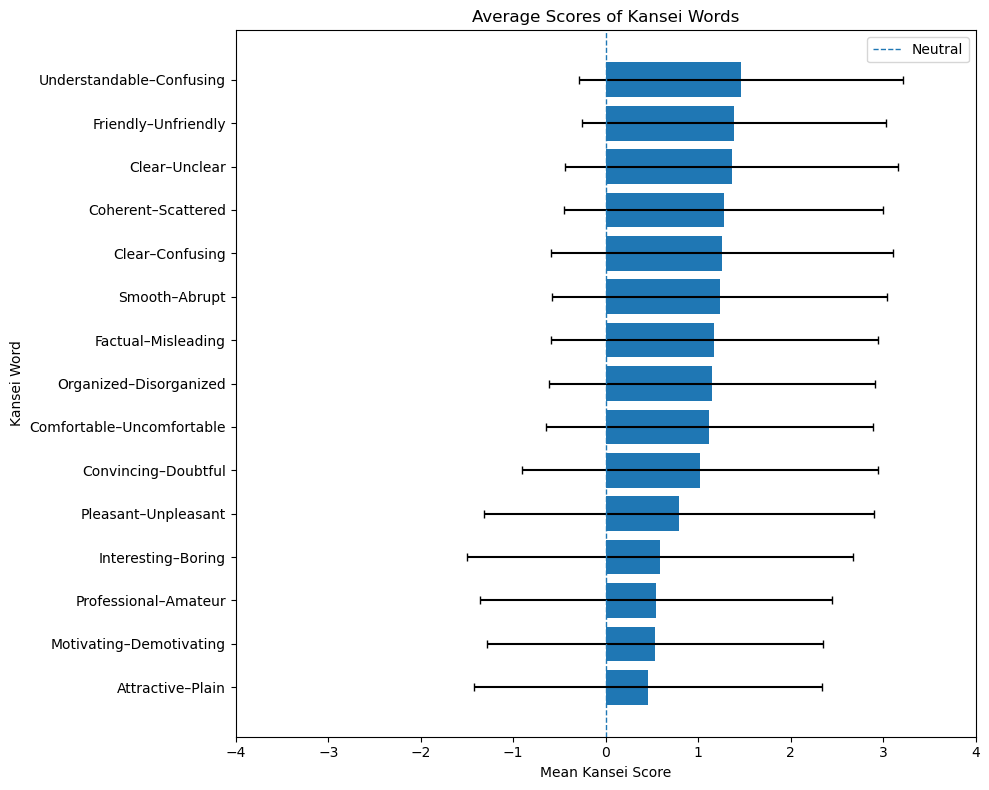

In [14]:
plot_data = kansei_summary.sort_values(
    by="Mean",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_data["Kansei Word"],
    plot_data["Mean"],
    xerr=plot_data["SD"],
    capsize=3
)

# Neutral point
plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1,
    label="Neutral"
)

plt.xlabel("Mean Kansei Score")
plt.ylabel("Kansei Word")
plt.title("Average Scores of Kansei Words")
plt.xlim(-4, 4)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
for dimension, columns in kansei_dimensions.items():
    df[f"{dimension}_Unweighted_Mean"] = df[columns].mean(
        axis=1,
        skipna=True
    )

dimension_summary = []

for dimension in kansei_dimensions.keys():
    score_column = f"{dimension}_Unweighted_Mean"

    dimension_summary.append({
        "Dimension": dimension,
        "Mean": df[score_column].mean(),
        "SD": df[score_column].std(ddof=1),
        "Median": df[score_column].median(),
        "Minimum": df[score_column].min(),
        "Maximum": df[score_column].max(),
        "N": df[score_column].count()
    })

dimension_summary = pd.DataFrame(dimension_summary)

display(dimension_summary.round(3))

,Dimension,Mean,SD,Median,Minimum,Maximum,N
0,Visual,1.054,1.521,1.4,-3.0,3.0,108
1,Content,0.957,1.582,1.3,-3.0,3.0,108
2,Audio_Narrator,1.063,1.644,1.4,-3.0,3.0,108


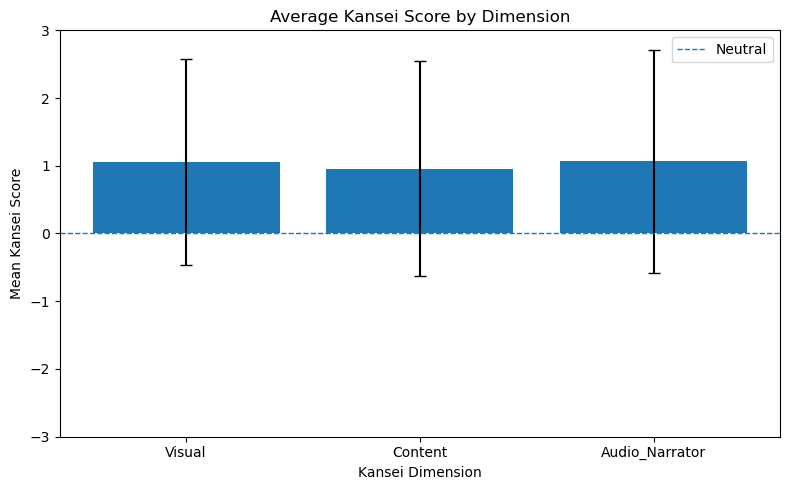

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    dimension_summary["Dimension"],
    dimension_summary["Mean"],
    yerr=dimension_summary["SD"],
    capsize=4
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
    label="Neutral"
)

plt.xlabel("Kansei Dimension")
plt.ylabel("Mean Kansei Score")
plt.title("Average Kansei Score by Dimension")
plt.ylim(-3, 3)
plt.legend()
plt.tight_layout()
plt.show()

### 1.2 Reliability Analysis

In [17]:
def cronbach_alpha(data):
    """
    Calculate Cronbach's alpha.

    Rows:
        Participant-video evaluations

    Columns:
        Kansei items
    """

    clean_data = data.dropna()

    number_of_items = clean_data.shape[1]

    if number_of_items < 2:
        return np.nan

    item_variances = clean_data.var(
        axis=0,
        ddof=1
    )

    total_score = clean_data.sum(axis=1)

    total_variance = total_score.var(ddof=1)

    if total_variance == 0 or pd.isna(total_variance):
        return np.nan

    alpha = (
        number_of_items /
        (number_of_items - 1)
    ) * (
        1 -
        item_variances.sum() /
        total_variance
    )

    return alpha

In [18]:
def interpret_alpha(alpha):
    if pd.isna(alpha):
        return "Cannot calculate"
    elif alpha >= 0.90:
        return "Excellent"
    elif alpha >= 0.80:
        return "Good"
    elif alpha >= 0.70:
        return "Acceptable"
    elif alpha >= 0.60:
        return "Questionable"
    elif alpha >= 0.50:
        return "Poor"
    else:
        return "Unacceptable"

In [19]:
reliability_results = []

for dimension, columns in kansei_dimensions.items():

    alpha = cronbach_alpha(df[columns])

    reliability_results.append({
        "Dimension": dimension,
        "Number of Items": len(columns),
        "Complete Evaluations": df[columns].dropna().shape[0],
        "Cronbach Alpha": alpha,
        "Interpretation": interpret_alpha(alpha)
    })

reliability_results = pd.DataFrame(
    reliability_results
)

display(reliability_results.round(3))

,Dimension,Number of Items,Complete Evaluations,Cronbach Alpha,Interpretation
0,Visual,5,108,0.900,Excellent
1,Content,5,108,0.893,Good
2,Audio_Narrator,5,108,0.936,Excellent


In [20]:
overall_alpha = cronbach_alpha(
    df[kansei_columns]
)

overall_reliability = pd.DataFrame({
    "Scale": ["All Kansei Words"],
    "Number of Items": [len(kansei_columns)],
    "Complete Evaluations": [
        df[kansei_columns].dropna().shape[0]
    ],
    "Cronbach Alpha": [overall_alpha],
    "Interpretation": [
        interpret_alpha(overall_alpha)
    ]
})

display(overall_reliability.round(3))

,Scale,Number of Items,Complete Evaluations,Cronbach Alpha,Interpretation
0,All Kansei Words,15,108,0.963,Excellent


In [21]:
def item_reliability_analysis(data):
    """
    Calculate corrected item-total correlation
    and Cronbach's alpha if each item is deleted.
    """

    clean_data = data.dropna()

    results = []

    for column in clean_data.columns:

        remaining_columns = [
            other_column
            for other_column in clean_data.columns
            if other_column != column
        ]

        other_item_total = clean_data[
            remaining_columns
        ].sum(axis=1)

        item_total_correlation = clean_data[
            column
        ].corr(other_item_total)

        alpha_if_deleted = cronbach_alpha(
            clean_data[remaining_columns]
        )

        results.append({
            "Column": column,
            "Kansei Word": kansei_labels[column],
            "Corrected Item-Total Correlation":
                item_total_correlation,
            "Cronbach Alpha if Deleted":
                alpha_if_deleted
        })

    return pd.DataFrame(results)

In [22]:
item_reliability_tables = {}

for dimension, columns in kansei_dimensions.items():

    print(f"\n{dimension} reliability details")

    item_table = item_reliability_analysis(
        df[columns]
    )

    item_reliability_tables[dimension] = item_table

    display(item_table.round(3))


Visual reliability details


,Column,Kansei Word,Corrected Item-Total Correlation,Cronbach Alpha if Deleted
0,attractive_plain,Attractive–Plain,0.623,0.907
1,clear_confusing,Clear–Confusing,0.778,0.872
2,organized_disorganized,Organized–Disorganized,0.786,0.871
3,comfortable_uncomfortable,Comfortable–Uncomfortable,0.800,0.868
4,coherent_scattered,Coherent–Scattered,0.785,0.872



Content reliability details


,Column,Kansei Word,Corrected Item-Total Correlation,Cronbach Alpha if Deleted
0,professional_amateur,Professional–Amateur,0.792,0.857
1,understandable_confusing,Understandable–Confusing,0.762,0.865
2,interesting_boring,Interesting–Boring,0.536,0.919
3,factual_misleading,Factual–Misleading,0.815,0.854
4,convincing_doubtful,Convincing–Doubtful,0.824,0.849



Audio_Narrator reliability details


,Column,Kansei Word,Corrected Item-Total Correlation,Cronbach Alpha if Deleted
0,pleasant_unpleasant,Pleasant–Unpleasant,0.863,0.918
1,clear_unclear,Clear–Unclear,0.863,0.916
2,smooth_abrupt,Smooth–Abrupt,0.866,0.915
3,friendly_unfriendly,Friendly–Unfriendly,0.851,0.920
4,motivating_demotivating,Motivating–Demotivating,0.730,0.940


### 1.3 Kansei Word Weight Calculation

In [23]:
weight_results = []

for dimension, columns in kansei_dimensions.items():

    standard_deviations = df[columns].std(
        ddof=1
    )

    sd_total = standard_deviations.sum()

    if sd_total == 0 or pd.isna(sd_total):
        # Equal weights if all standard deviations are zero
        normalized_weights = pd.Series(
            1 / len(columns),
            index=columns
        )
    else:
        normalized_weights = (
            standard_deviations / sd_total
        )

    for column in columns:
        weight_results.append({
            "Dimension": dimension,
            "Column": column,
            "Kansei Word": kansei_labels[column],
            "Mean": df[column].mean(),
            "SD": standard_deviations[column],
            "Within-Dimension Weight":
                normalized_weights[column]
        })

weight_table = pd.DataFrame(weight_results)

display(weight_table.round(4))

,Dimension,Column,Kansei Word,Mean,SD,Within-Dimension Weight
0,Visual,attractive_plain,Attractive–Plain,0.4630,1.8817,0.2093
1,Visual,clear_confusing,Clear–Confusing,1.2593,1.8513,0.2059
2,Visual,organized_disorganized,Organized–Disorganized,1.1481,1.7658,0.1964
3,Visual,comfortable_uncomfortable,Comfortable–Uncomfortable,1.1204,1.7706,0.1969
4,Visual,coherent_scattered,Coherent–Scattered,1.2778,1.7230,0.1916
5,Content,professional_amateur,Professional–Amateur,0.5463,1.9012,0.2015
6,Content,understandable_confusing,Understandable–Confusing,1.4630,1.7478,0.1852
7,Content,interesting_boring,Interesting–Boring,0.5833,2.0875,0.2212
8,Content,factual_misleading,Factual–Misleading,1.1759,1.7712,0.1877
9,Content,convincing_doubtful,Convincing–Doubtful,1.0185,1.9285,0.2044


In [24]:
weight_check = (
    weight_table
    .groupby("Dimension")[
        "Within-Dimension Weight"
    ]
    .sum()
    .reset_index(name="Weight Sum")
)

display(weight_check.round(6))

,Dimension,Weight Sum
0,Audio_Narrator,1.0
1,Content,1.0
2,Visual,1.0


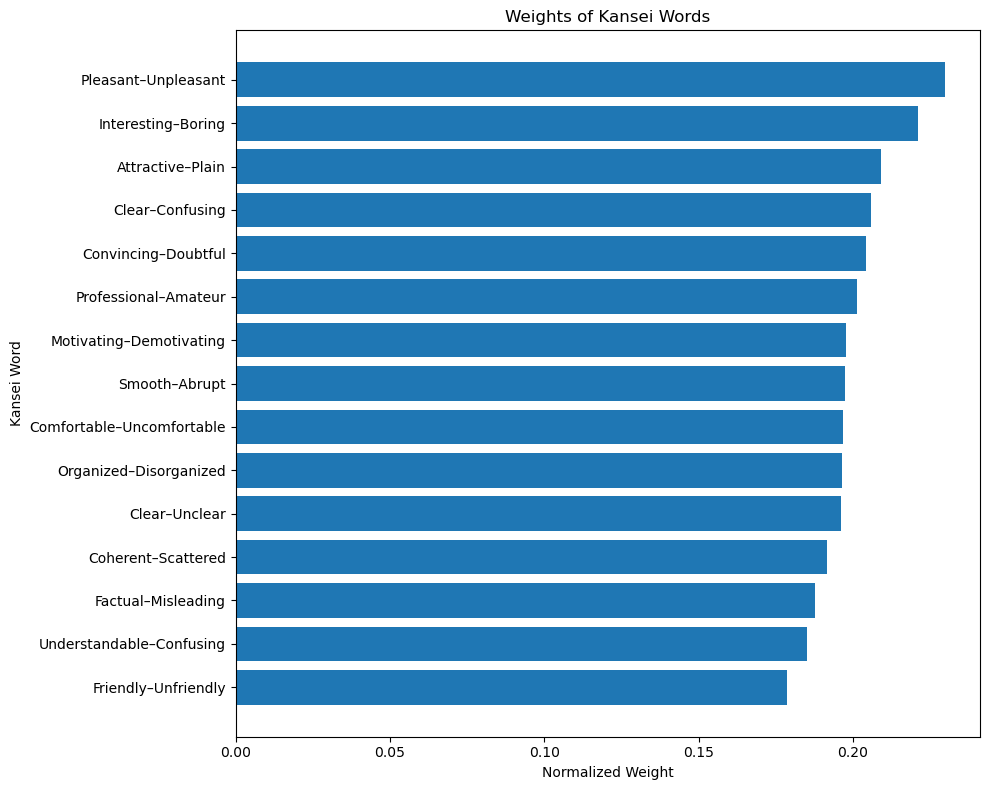

In [25]:
weight_plot = weight_table.sort_values(
    by="Within-Dimension Weight",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    weight_plot["Kansei Word"],
    weight_plot["Within-Dimension Weight"]
)

plt.xlabel("Normalized Weight")
plt.ylabel("Kansei Word")
plt.title("Weights of Kansei Words")
plt.tight_layout()
plt.show()

In [26]:
number_of_dimensions = len(
    kansei_dimensions
)

dimension_weight = (
    1 / number_of_dimensions
)

weight_table["Dimension Weight"] = (
    dimension_weight
)

weight_table["Overall Weight"] = (
    weight_table["Within-Dimension Weight"] *
    weight_table["Dimension Weight"]
)

display(weight_table.round(4))

,Dimension,Column,Kansei Word,Mean,SD,Within-Dimension Weight,Dimension Weight,Overall Weight
0,Visual,attractive_plain,Attractive–Plain,0.4630,1.8817,0.2093,0.3333,0.0698
1,Visual,clear_confusing,Clear–Confusing,1.2593,1.8513,0.2059,0.3333,0.0686
2,Visual,organized_disorganized,Organized–Disorganized,1.1481,1.7658,0.1964,0.3333,0.0655
3,Visual,comfortable_uncomfortable,Comfortable–Uncomfortable,1.1204,1.7706,0.1969,0.3333,0.0656
4,Visual,coherent_scattered,Coherent–Scattered,1.2778,1.7230,0.1916,0.3333,0.0639
5,Content,professional_amateur,Professional–Amateur,0.5463,1.9012,0.2015,0.3333,0.0672
6,Content,understandable_confusing,Understandable–Confusing,1.4630,1.7478,0.1852,0.3333,0.0617
7,Content,interesting_boring,Interesting–Boring,0.5833,2.0875,0.2212,0.3333,0.0737
8,Content,factual_misleading,Factual–Misleading,1.1759,1.7712,0.1877,0.3333,0.0626
9,Content,convincing_doubtful,Convincing–Doubtful,1.0185,1.9285,0.2044,0.3333,0.0681


In [27]:
overall_weight_sum = (
    weight_table["Overall Weight"].sum()
)

print(
    "Sum of overall weights:",
    round(overall_weight_sum, 6)
)

Sum of overall weights: 1.0


In [28]:
within_dimension_weights = {}

for dimension in kansei_dimensions.keys():

    dimension_rows = weight_table[
        weight_table["Dimension"] == dimension
    ]

    within_dimension_weights[dimension] = (
        dimension_rows
        .set_index("Column")[
            "Within-Dimension Weight"
        ]
        .to_dict()
    )

In [29]:
overall_weights = (
    weight_table
    .set_index("Column")[
        "Overall Weight"
    ]
    .to_dict()
)

print("Within-dimension weights:")
print(within_dimension_weights)

print("\nOverall weights:")
print(overall_weights)

Within-dimension weights:
{'Visual': {'attractive_plain': 0.20925058580008102, 'clear_confusing': 0.20587876489577575, 'organized_disorganized': 0.1963650904357679, 'comfortable_uncomfortable': 0.19689572328630583, 'coherent_scattered': 0.1916098355820695}, 'Content': {'professional_amateur': 0.20148326196209135, 'understandable_confusing': 0.18522043073950917, 'interesting_boring': 0.22121921011369505, 'factual_misleading': 0.18769881586018577, 'convincing_doubtful': 0.20437828132451874}, 'Audio_Narrator': {'pleasant_unpleasant': 0.2297395736172808, 'clear_unclear': 0.19622967103019615, 'smooth_abrupt': 0.19744100903006445, 'friendly_unfriendly': 0.17868860726042357, 'motivating_demotivating': 0.19790113906203494}}

Overall weights:
{'attractive_plain': 0.06975019526669367, 'clear_confusing': 0.06862625496525858, 'organized_disorganized': 0.06545503014525596, 'comfortable_uncomfortable': 0.06563190776210194, 'coherent_scattered': 0.06386994519402317, 'professional_amateur': 0.06716108

### 1.4 Kansei Score Calculation

In [30]:
def weighted_score_with_missing(data, columns, weights):
    """
    Calculate a weighted Kansei Score while handling missing values.

    Parameters
    ----------
    data : pandas.DataFrame
        Dataset containing the Kansei ratings.

    columns : list
        Kansei columns included in the score.

    weights : dict
        Dictionary containing the weight of each Kansei word.

    Returns
    -------
    pandas.Series
        Weighted scores on the -3 to 3 scale.
    """

    # Convert the weight dictionary into a Series
    weight_series = pd.Series(weights).reindex(columns)

    # Multiply each Kansei rating by its weight
    weighted_values = data[columns].mul(
        weight_series,
        axis=1
    )

    # Calculate the total available weight for each row
    available_weights = (
        data[columns]
        .notna()
        .mul(weight_series, axis=1)
        .sum(axis=1)
    )

    # Calculate the weighted sum
    weighted_sum = weighted_values.sum(
        axis=1,
        min_count=1
    )

    # Divide by the available weight
    weighted_score = (
        weighted_sum /
        available_weights.replace(0, np.nan)
    )

    return weighted_score

In [34]:
for dimension, columns in kansei_dimensions.items():

    score_column = f"{dimension}_Kansei_Score"

    df[score_column] = weighted_score_with_missing(
        data=df,
        columns=columns,
        weights=within_dimension_weights[dimension]
    )

dimension_score_columns = [
    f"{dimension}_Kansei_Score"
    for dimension in kansei_dimensions
]

display(
    df[
        [
            "participant_id",
            "group",
            "video_id",
            "video_id_count"
        ] +
        dimension_score_columns
    ].head(24).round(3)
)

,participant_id,group,video_id,video_id_count,Visual_Kansei_Score,Content_Kansei_Score,Audio_Narrator_Kansei_Score
0,P-20260711T030347Z-C30B56,B,S02,V22,2.581,3.000,3.000
1,P-20260711T030347Z-C30B56,B,H04,V16,3.000,1.981,2.445
2,P-20260711T030347Z-C30B56,B,L03,V19,2.581,2.558,2.821
3,P-20260711T030347Z-C30B56,B,S04,V24,1.590,0.968,0.569
4,P-20260711T030347Z-C30B56,B,H01,V13,3.000,2.017,1.182
5,P-20260711T030347Z-C30B56,B,H03,V15,-1.803,-2.204,-0.444
6,P-20260711T030347Z-C30B56,B,L01,V17,3.000,2.222,3.000
7,P-20260711T030347Z-C30B56,B,S03,V23,3.000,2.423,2.803
8,P-20260711T030347Z-C30B56,B,L04,V20,2.042,1.978,3.000
9,P-20260711T030347Z-C30B56,B,S01,V21,3.000,3.000,3.000


In [35]:
df["Overall_Kansei_Score"] = (
    df[dimension_score_columns]
    .mean(axis=1, skipna=True)
)

display(
    df[
        [
            "participant_id",
            "group",
            "video_id",
            "video_id_count",
            "Visual_Kansei_Score",
            "Content_Kansei_Score",
            "Audio_Narrator_Kansei_Score",
            "Overall_Kansei_Score"
        ]
    ].head(20).round(3)
)

,participant_id,group,video_id,video_id_count,Visual_Kansei_Score,Content_Kansei_Score,Audio_Narrator_Kansei_Score,Overall_Kansei_Score
0,P-20260711T030347Z-C30B56,B,S02,V22,2.581,3.000,3.000,2.860
1,P-20260711T030347Z-C30B56,B,H04,V16,3.000,1.981,2.445,2.475
2,P-20260711T030347Z-C30B56,B,L03,V19,2.581,2.558,2.821,2.653
3,P-20260711T030347Z-C30B56,B,S04,V24,1.590,0.968,0.569,1.042
4,P-20260711T030347Z-C30B56,B,H01,V13,3.000,2.017,1.182,2.066
5,P-20260711T030347Z-C30B56,B,H03,V15,-1.803,-2.204,-0.444,-1.484
6,P-20260711T030347Z-C30B56,B,L01,V17,3.000,2.222,3.000,2.741
7,P-20260711T030347Z-C30B56,B,S03,V23,3.000,2.423,2.803,2.742
8,P-20260711T030347Z-C30B56,B,L04,V20,2.042,1.978,3.000,2.340
9,P-20260711T030347Z-C30B56,B,S01,V21,3.000,3.000,3.000,3.000


In [30]:
all_score_columns = (
    dimension_score_columns +
    ["Overall_Kansei_Score"]
)

score_range_check = pd.DataFrame({
    "Minimum": df[all_score_columns].min(),
    "Maximum": df[all_score_columns].max(),
    "Mean": df[all_score_columns].mean(),
    "SD": df[all_score_columns].std(ddof=1)
})

display(score_range_check.round(3))

,Minimum,Maximum,Mean,SD
Visual_Kansei_Score,-3.000,3.0,1.047,1.521
Content_Kansei_Score,-3.000,3.0,0.939,1.583
Audio_Narrator_Kansei_Score,-3.000,3.0,1.048,1.657
Overall_Kansei_Score,-2.923,3.0,1.011,1.501


In [36]:
all_score_columns = (
    dimension_score_columns +
    ["Overall_Kansei_Score"]
)

score_range_check = pd.DataFrame({
    "Minimum": df[all_score_columns].min(),
    "Maximum": df[all_score_columns].max(),
    "Mean": df[all_score_columns].mean(),
    "SD": df[all_score_columns].std(ddof=1),
    "N": df[all_score_columns].count()
})

display(score_range_check.round(3))

,Minimum,Maximum,Mean,SD,N
Visual_Kansei_Score,-3.000,3.0,1.047,1.521,108
Content_Kansei_Score,-3.000,3.0,0.939,1.583,108
Audio_Narrator_Kansei_Score,-3.000,3.0,1.048,1.657,108
Overall_Kansei_Score,-2.923,3.0,1.011,1.501,108


In [44]:
participant_score_summary = (
    df[all_score_columns]
    .describe()
    .T
)

display(
    participant_score_summary.round(3)
)

,count,mean,std,min,25%,50%,75%,max
Visual_Kansei_Score,108.0,-1.047,1.521,-3.0,-2.191,-1.386,0.023,3.000
Content_Kansei_Score,108.0,-0.939,1.583,-3.0,-2.051,-1.260,0.067,3.000
Audio_Narrator_Kansei_Score,108.0,-1.048,1.657,-3.0,-2.411,-1.373,0.124,3.000
Overall_Kansei_Score,108.0,-1.011,1.501,-3.0,-2.143,-1.294,-0.117,2.923


In [37]:
invalid_scores = (
    (df[all_score_columns] < -3) |
    (df[all_score_columns] > 3)
)

number_of_invalid_scores = invalid_scores.sum().sum()

if number_of_invalid_scores == 0:
    print(
        "All Kansei Scores are within "
        "the valid range of -3 to 3."
    )
else:
    print(
        f"Warning: {number_of_invalid_scores} "
        "scores are outside the range of -3 to 3."
    )

All Kansei Scores are within the valid range of -3 to 3.


In [38]:
participant_score_summary = (
    df[all_score_columns]
    .describe()
    .T
)

display(participant_score_summary.round(3))

,count,mean,std,min,25%,50%,75%,max
Visual_Kansei_Score,108.0,1.047,1.521,-3.000,-0.023,1.386,2.191,3.0
Content_Kansei_Score,108.0,0.939,1.583,-3.000,-0.067,1.260,2.051,3.0
Audio_Narrator_Kansei_Score,108.0,1.048,1.657,-3.000,-0.124,1.373,2.411,3.0
Overall_Kansei_Score,108.0,1.011,1.501,-2.923,0.117,1.294,2.143,3.0


In [44]:
video_mapping_check = (
    df[
        [
            "video_id_count",
            "group",
            "video_id",
            "video_title",
            "topic"
        ]
    ]
    .drop_duplicates()
    .sort_values("video_id_count")
)

print(
    "Number of unique videos:",
    video_mapping_check["video_id_count"].nunique()
)

Number of unique videos: 24


In [40]:
video_kansei_scores = (
    df.groupby(
        "video_id_count",
        dropna=False
    )
    .agg(
        Group=(
            "group",
            "first"
        ),

        Original_Video_ID=(
            "video_id",
            "first"
        ),

        Video_Title=(
            "video_title",
            "first"
        ),

        Topic=(
            "topic",
            "first"
        ),

        Visual_Kansei_Mean=(
            "Visual_Kansei_Score",
            "mean"
        ),

        Visual_Kansei_SD=(
            "Visual_Kansei_Score",
            "std"
        ),

        Content_Kansei_Mean=(
            "Content_Kansei_Score",
            "mean"
        ),

        Content_Kansei_SD=(
            "Content_Kansei_Score",
            "std"
        ),

        Audio_Narrator_Kansei_Mean=(
            "Audio_Narrator_Kansei_Score",
            "mean"
        ),

        Audio_Narrator_Kansei_SD=(
            "Audio_Narrator_Kansei_Score",
            "std"
        ),

        Overall_Kansei_Mean=(
            "Overall_Kansei_Score",
            "mean"
        ),

        Overall_Kansei_SD=(
            "Overall_Kansei_Score",
            "std"
        ),

        Number_of_Evaluations=(
            "Overall_Kansei_Score",
            "count"
        )
    )
    .reset_index()
    .sort_values("video_id_count")
)

print(
    "Number of videos:",
    video_kansei_scores["video_id_count"].nunique()
)

display(video_kansei_scores.round(3))

Number of videos: 24


,video_id_count,Group,Original_Video_ID,Video_Title,Topic,Visual_Kansei_Mean,Visual_Kansei_SD,Content_Kansei_Mean,Content_Kansei_SD,Audio_Narrator_Kansei_Mean,Audio_Narrator_Kansei_SD,Overall_Kansei_Mean,Overall_Kansei_SD,Number_of_Evaluations
0,V01,A,H01,Video A01,History,-0.521,1.689,-0.573,1.732,-0.866,1.507,-0.654,1.536,5
1,V02,A,H02,Video A02,History,-0.517,1.500,-0.285,1.383,-1.079,1.316,-0.627,1.339,5
2,V03,A,H03,Video A03,History,1.438,0.921,1.301,0.886,1.389,0.758,1.376,0.816,5
3,V04,A,H04,Video A05,History,-0.392,1.938,0.434,1.029,-0.267,2.064,-0.075,1.622,5
4,V05,A,L01,Video A09,Language Learning,2.188,0.655,2.098,0.758,1.989,1.025,2.092,0.794,5
5,V06,A,L02,Video A06,Language Learning,1.073,1.752,0.729,2.150,1.261,1.385,1.021,1.731,5
6,V07,A,L03,Video A06,Language Learning,2.109,1.146,1.833,1.241,2.058,1.273,2.000,1.203,5
7,V08,A,L04,Video A06,Language Learning,0.761,1.342,0.475,1.587,0.924,0.657,0.720,1.100,5
8,V09,A,S01,Video A04,Science,-0.337,1.328,-0.983,1.724,-0.815,1.151,-0.712,1.320,5
9,V10,A,S02,Video A07,Science,2.277,0.920,1.977,0.953,2.156,0.839,2.137,0.852,5


In [42]:
video_kansei_scores["Video_Label"] = (
    "Group "
    + video_kansei_scores["group"].astype(str)
    + " - "
    + video_kansei_scores["video_id_count"].astype(str)
)

display(
    video_kansei_scores[
        [
            "Video_Label",
            "Original_Video_ID",
            "Video_Title",
            "Topic"
        ]
    ]
)

,Video_Label,Original_Video_ID,Video_Title,Topic
0,Group A - V01,H01,Video A01,History
1,Group A - V02,H02,Video A02,History
2,Group A - V03,H03,Video A03,History
3,Group A - V04,H04,Video A05,History
4,Group A - V05,L01,Video A09,Language Learning
5,Group A - V06,L02,Video A06,Language Learning
6,Group A - V07,L03,Video A06,Language Learning
7,Group A - V08,L04,Video A06,Language Learning
8,Group A - V09,S01,Video A04,Science
9,Group A - V10,S02,Video A07,Science


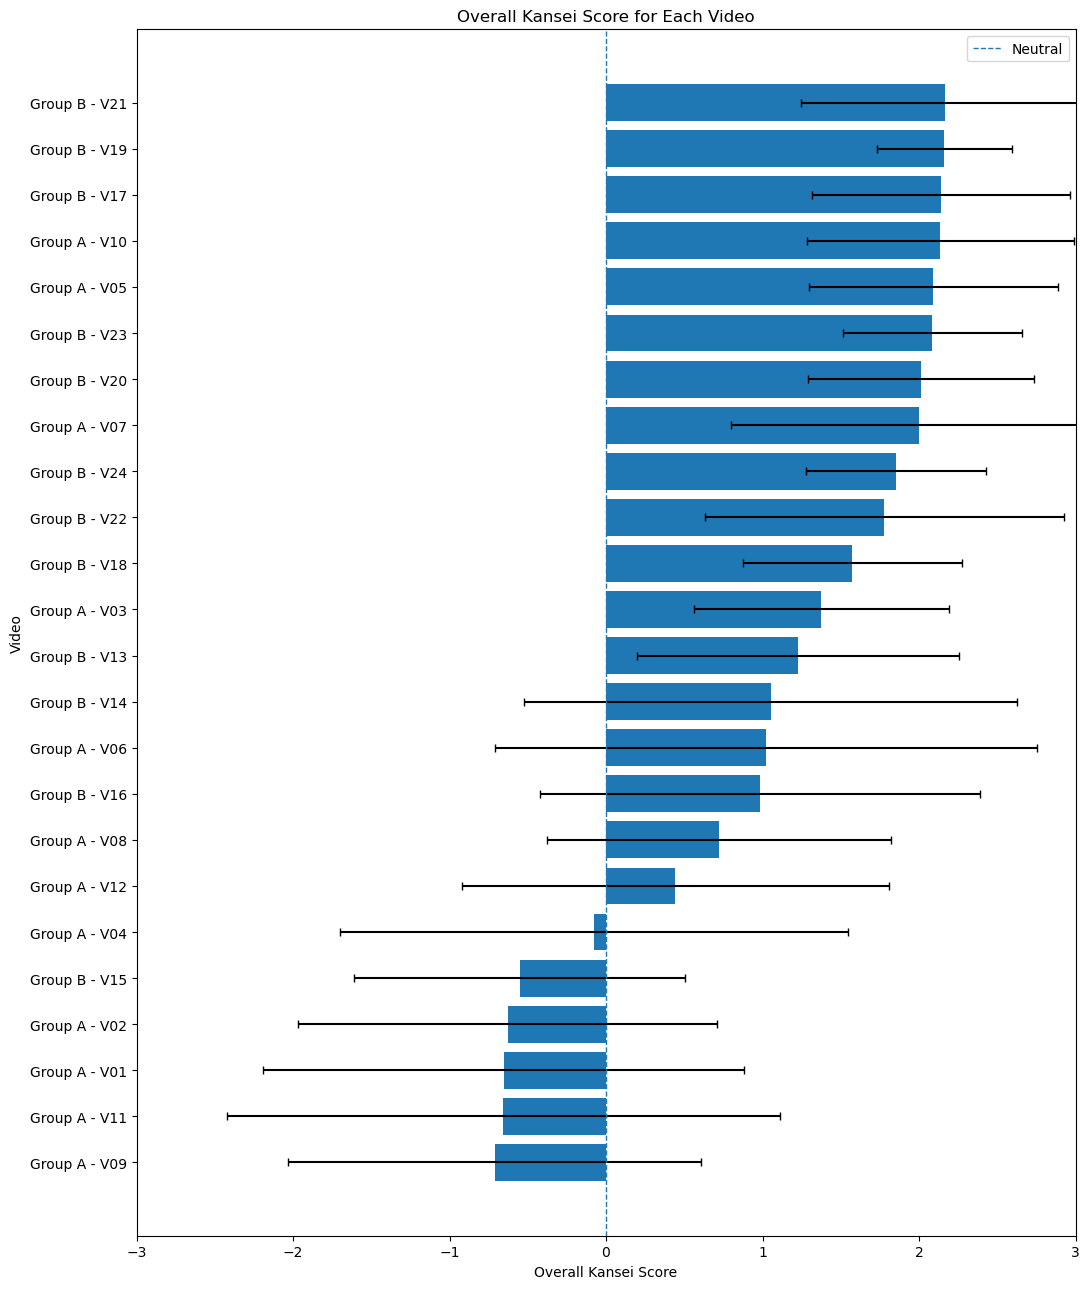

In [43]:
plot_video_scores = (
    video_kansei_scores
    .sort_values(
        "Overall_Kansei_Mean",
        ascending=True
    )
)

plt.figure(figsize=(11, 13))

plt.barh(
    plot_video_scores["Video_Label"],
    plot_video_scores["Overall_Kansei_Mean"],
    xerr=plot_video_scores["Overall_Kansei_SD"],
    capsize=3
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1,
    label="Neutral"
)

plt.xlabel("Overall Kansei Score")
plt.ylabel("Video")
plt.title("Overall Kansei Score for Each Video")
plt.xlim(-3, 3)
plt.legend()

plt.tight_layout()
plt.show()

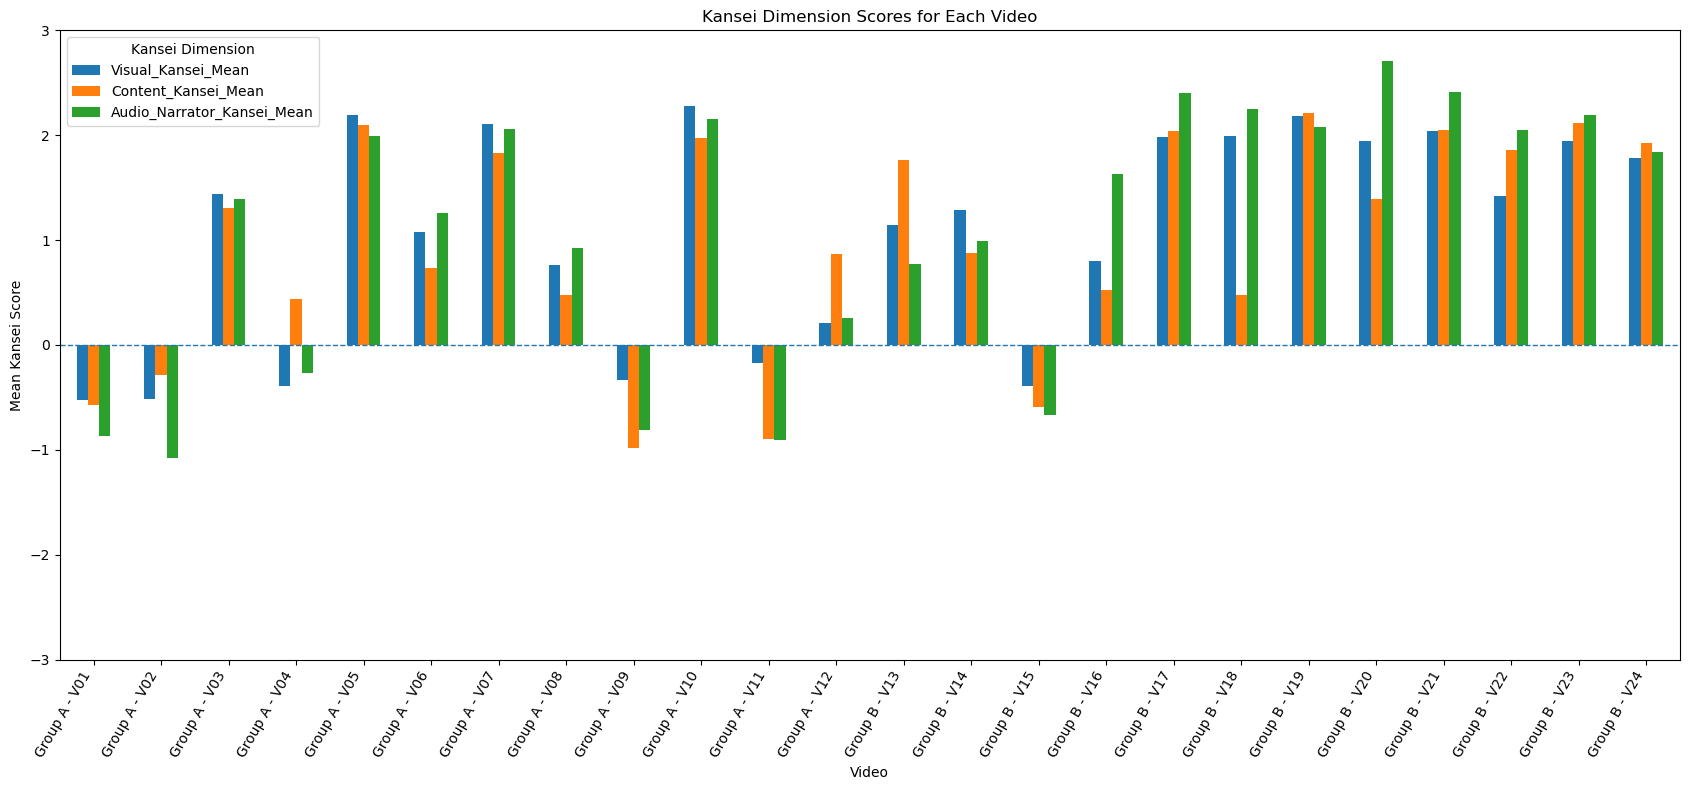

In [45]:
video_dimension_scores = (
    video_kansei_scores[
        [
            "Video_Label",
            "Visual_Kansei_Mean",
            "Content_Kansei_Mean",
            "Audio_Narrator_Kansei_Mean"
        ]
    ]
    .set_index("Video_Label")
)

video_dimension_scores.plot(
    kind="bar",
    figsize=(17, 8)
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Video")
plt.ylabel("Mean Kansei Score")
plt.title("Kansei Dimension Scores for Each Video")
plt.ylim(-3, 3)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.legend(
    title="Kansei Dimension"
)

plt.tight_layout()
plt.show()

In [47]:
df["Video_Label"] = (
    "Group "
    + df["group"].astype(str)
    + " - "
    + df["video_id_count"].astype(str)
)

video_word_means = (
    df.groupby("Video_Label")[
        kansei_columns
    ]
    .mean()
)

video_word_means = video_word_means.rename(
    columns=kansei_labels
)

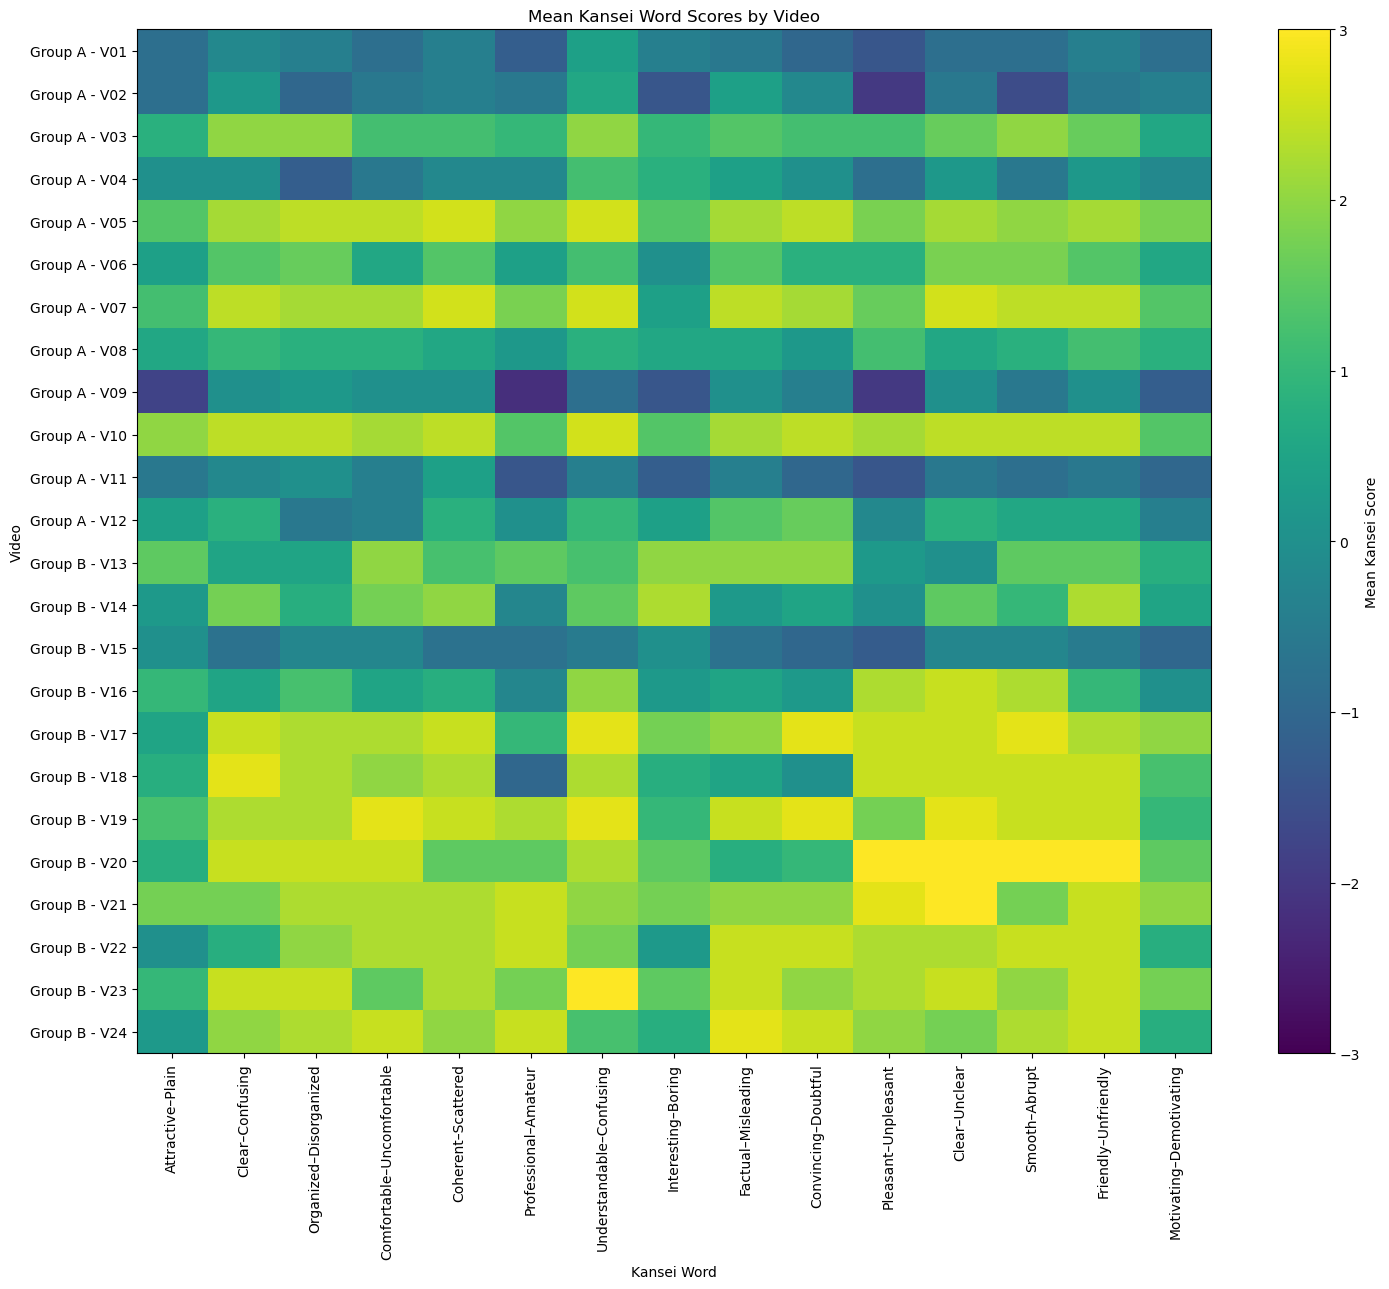

In [48]:
plt.figure(figsize=(15, 13))

heatmap = plt.imshow(
    video_word_means,
    aspect="auto",
    vmin=-3,
    vmax=3
)

plt.colorbar(
    heatmap,
    label="Mean Kansei Score"
)

plt.xticks(
    ticks=range(
        len(video_word_means.columns)
    ),
    labels=video_word_means.columns,
    rotation=90
)

plt.yticks(
    ticks=range(
        len(video_word_means.index)
    ),
    labels=video_word_means.index
)

plt.xlabel("Kansei Word")
plt.ylabel("Video")
plt.title("Mean Kansei Word Scores by Video")

plt.tight_layout()
plt.show()

## 2. Topic Analysis

In [52]:
print(df["topic"].unique())

['Science' 'History' 'Language Learning']


In [53]:
df["topic"] = (
    df["topic"]
    .astype(str)
    .str.strip()
    .str.lower()
)

topic_name_map = {
    "language": "Language",
    "language learning": "Language",
    "language_learning": "Language",

    "science": "Science",

    "history": "History"
}

df["Topic"] = df["topic"].map(topic_name_map)

print(df["Topic"].value_counts(dropna=False))

Topic
Science     36
History     36
Language    36
Name: count, dtype: int64


In [54]:
unmapped_topics = df.loc[
    df["Topic"].isna(),
    "topic"
].unique()

print("Unmapped topic names:", unmapped_topics)

Unmapped topic names: []


In [55]:
topic_order = [
    "Language",
    "Science",
    "History"
]

df["Topic"] = pd.Categorical(
    df["Topic"],
    categories=topic_order,
    ordered=True
)

topic_data_check = (
    df.groupby("Topic", observed=False)
    .agg(
        Number_of_Rows=(
            "Overall_Kansei_Score",
            "count"
        ),
        Number_of_Participants=(
            "participant_id",
            "nunique"
        ),
        Number_of_Videos=(
            "video_id_count",
            "nunique"
        )
    )
    .reset_index()
)

display(topic_data_check)

,Topic,Number_of_Rows,Number_of_Participants,Number_of_Videos
0,Language,36,9,8
1,Science,36,9,8
2,History,36,9,8


### 2.1 Overall Kansei Score by Topic

In [56]:
def confidence_interval_95(series):
    """
    Return the lower and upper limits of the
    95% confidence interval for a numeric series.
    """

    clean = series.dropna()
    n = len(clean)

    if n < 2:
        return pd.Series({
            "CI_Lower": np.nan,
            "CI_Upper": np.nan
        })

    mean = clean.mean()
    standard_error = stats.sem(clean)

    margin = stats.t.ppf(
        0.975,
        df=n - 1
    ) * standard_error

    return pd.Series({
        "CI_Lower": mean - margin,
        "CI_Upper": mean + margin
    })

In [57]:
overall_topic_summary = (
    df.groupby("Topic", observed=False)[
        "Overall_Kansei_Score"
    ]
    .agg(
        Mean="mean",
        SD="std",
        Median="median",
        Minimum="min",
        Maximum="max",
        N="count"
    )
    .reset_index()
)

overall_ci = (
    df.groupby("Topic", observed=False)[
        "Overall_Kansei_Score"
    ]
    .apply(confidence_interval_95)
    .unstack()
    .reset_index()
)

overall_topic_summary = overall_topic_summary.merge(
    overall_ci,
    on="Topic",
    how="left"
)

display(overall_topic_summary.round(3))

,Topic,Mean,SD,Median,Minimum,Maximum,N,CI_Lower,CI_Upper
0,Language,1.687,1.085,1.920,-1.728,3.0,36,1.320,2.054
1,Science,1.043,1.604,1.203,-2.548,3.0,36,0.501,1.586
2,History,0.304,1.468,0.193,-2.923,3.0,36,-0.193,0.801


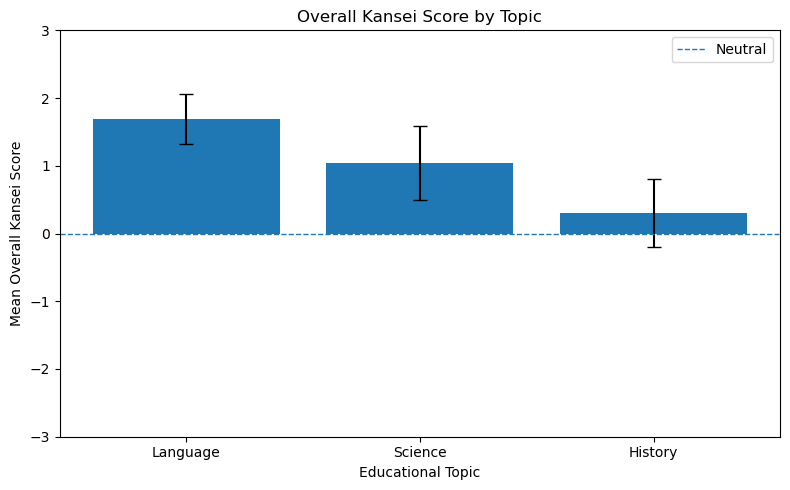

In [58]:
plot_summary = (
    overall_topic_summary
    .set_index("Topic")
    .reindex(topic_order)
    .reset_index()
)

lower_error = (
    plot_summary["Mean"] -
    plot_summary["CI_Lower"]
)

upper_error = (
    plot_summary["CI_Upper"] -
    plot_summary["Mean"]
)

plt.figure(figsize=(8, 5))

plt.bar(
    plot_summary["Topic"],
    plot_summary["Mean"],
    yerr=np.vstack([
        lower_error,
        upper_error
    ]),
    capsize=5
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
    label="Neutral"
)

plt.xlabel("Educational Topic")
plt.ylabel("Mean Overall Kansei Score")
plt.title("Overall Kansei Score by Topic")
plt.ylim(-3, 3)
plt.legend()
plt.tight_layout()
plt.show()

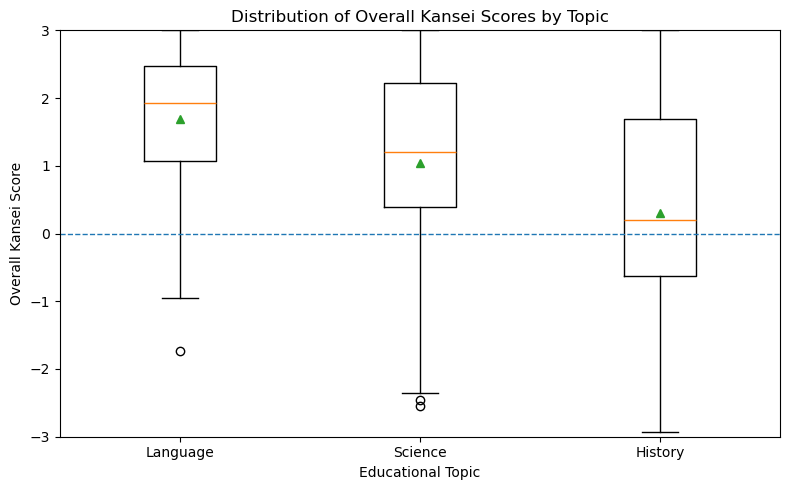

In [59]:
boxplot_values = [
    df.loc[
        df["Topic"] == topic,
        "Overall_Kansei_Score"
    ].dropna()
    for topic in topic_order
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    boxplot_values,
    tick_labels=topic_order,
    showmeans=True
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Educational Topic")
plt.ylabel("Overall Kansei Score")
plt.title("Distribution of Overall Kansei Scores by Topic")
plt.ylim(-3, 3)
plt.tight_layout()
plt.show()

In [60]:
participant_topic_scores = (
    df.groupby(
        ["participant_id", "Topic"],
        observed=False
    )
    .agg(
        Overall_Kansei_Score=(
            "Overall_Kansei_Score",
            "mean"
        ),
        Visual_Kansei_Score=(
            "Visual_Kansei_Score",
            "mean"
        ),
        Content_Kansei_Score=(
            "Content_Kansei_Score",
            "mean"
        ),
        Audio_Narrator_Kansei_Score=(
            "Audio_Narrator_Kansei_Score",
            "mean"
        ),
        Number_of_Videos=(
            "video_id_count",
            "nunique"
        )
    )
    .reset_index()
)

display(participant_topic_scores.head().round(3))

,participant_id,Topic,Overall_Kansei_Score,Visual_Kansei_Score,Content_Kansei_Score,Audio_Narrator_Kansei_Score,Number_of_Videos
0,P-20260709T052634Z-F27519,Language,2.541,2.446,2.420,2.758,4
1,P-20260709T052634Z-F27519,Science,2.452,2.336,2.378,2.643,4
2,P-20260709T052634Z-F27519,History,0.801,0.213,1.070,1.121,4
3,P-20260709T074312Z-5E8136,Language,2.142,1.900,2.228,2.298,4
4,P-20260709T074312Z-5E8136,Science,0.917,0.693,0.892,1.166,4


In [61]:
participant_topic_count = (
    participant_topic_scores
    .dropna(subset=["Overall_Kansei_Score"])
    .groupby("participant_id")["Topic"]
    .nunique()
)

print(participant_topic_count.value_counts().sort_index())

Topic
3    9
Name: count, dtype: int64


### 2.2 Kansei Dimension Comparison by Topic

In [64]:
dimension_score_columns = [
    "Visual_Kansei_Score",
    "Content_Kansei_Score",
    "Audio_Narrator_Kansei_Score"
]

dimension_readable_names = {
    "Visual_Kansei_Score": "Visual",
    "Content_Kansei_Score": "Content",
    "Audio_Narrator_Kansei_Score":
        "Audio & Narrator"
}

topic_dimension_long = df.melt(
    id_vars=[
        "participant_id",
        "Topic",
        "video_id_count"
    ],
    value_vars=dimension_score_columns,
    var_name="Dimension",
    value_name="Kansei_Score"
)

topic_dimension_long["Dimension"] = (
    topic_dimension_long["Dimension"]
    .map(dimension_readable_names)
)

topic_dimension_summary = (
    topic_dimension_long
    .groupby(
        ["Topic", "Dimension"],
        observed=False
    )["Kansei_Score"]
    .agg(
        Mean="mean",
        SD="std",
        Median="median",
        N="count"
    )
    .reset_index()
)

display(topic_dimension_summary.round(3))

,Topic,Dimension,Mean,SD,Median,N
0,Language,Audio & Narrator,1.915,1.034,2.103,36
1,Language,Content,1.393,1.381,1.796,36
2,Language,Visual,1.752,1.110,2.000,36
3,Science,Audio & Narrator,1.040,1.813,1.791,36
4,Science,Content,1.017,1.734,1.316,36
5,Science,Visual,1.073,1.455,1.016,36
6,History,Audio & Narrator,0.188,1.584,-0.052,36
7,History,Content,0.407,1.496,0.713,36
8,History,Visual,0.317,1.633,0.384,36


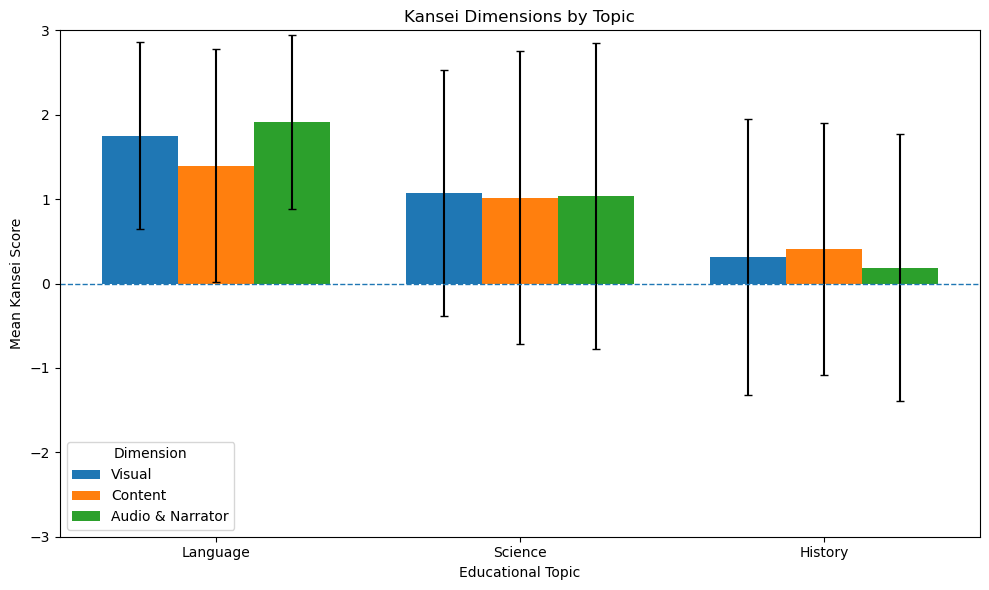

In [65]:
dimension_order = [
    "Visual",
    "Content",
    "Audio & Narrator"
]

x = np.arange(len(topic_order))
bar_width = 0.25

plt.figure(figsize=(10, 6))

for index, dimension in enumerate(dimension_order):

    dimension_data = (
        topic_dimension_summary[
            topic_dimension_summary[
                "Dimension"
            ] == dimension
        ]
        .set_index("Topic")
        .reindex(topic_order)
    )

    plt.bar(
        x + index * bar_width,
        dimension_data["Mean"],
        width=bar_width,
        yerr=dimension_data["SD"],
        capsize=3,
        label=dimension
    )

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xticks(
    x + bar_width,
    topic_order
)

plt.xlabel("Educational Topic")
plt.ylabel("Mean Kansei Score")
plt.title("Kansei Dimensions by Topic")
plt.ylim(-3, 3)
plt.legend(title="Dimension")
plt.tight_layout()
plt.show()

### 2.3 Individual Kansei Word Comparison

In [66]:
topic_word_means = (
    df.groupby(
        "Topic",
        observed=False
    )[kansei_columns]
    .mean()
    .reindex(topic_order)
)

topic_word_means_readable = (
    topic_word_means
    .rename(columns=kansei_labels)
)

display(topic_word_means_readable.round(3))

,Attractive–Plain,Clear–Confusing,Organized–Disorganized,Comfortable–Uncomfortable,Coherent–Scattered,Professional–Amateur,Understandable–Confusing,Interesting–Boring,Factual–Misleading,Convincing–Doubtful,Pleasant–Unpleasant,Clear–Unclear,Smooth–Abrupt,Friendly–Unfriendly,Motivating–Demotivating
Topic,,,,,,,,,,,,,,,
Language,0.861,2.083,2.000,1.889,1.972,1.028,2.111,0.889,1.556,1.500,1.833,2.194,2.167,2.139,1.278
Science,0.333,1.194,1.278,1.139,1.472,0.722,1.222,0.361,1.528,1.361,0.833,1.417,1.167,1.444,0.417
History,0.194,0.500,0.167,0.333,0.389,-0.111,1.056,0.500,0.444,0.194,-0.278,0.472,0.361,0.583,-0.083


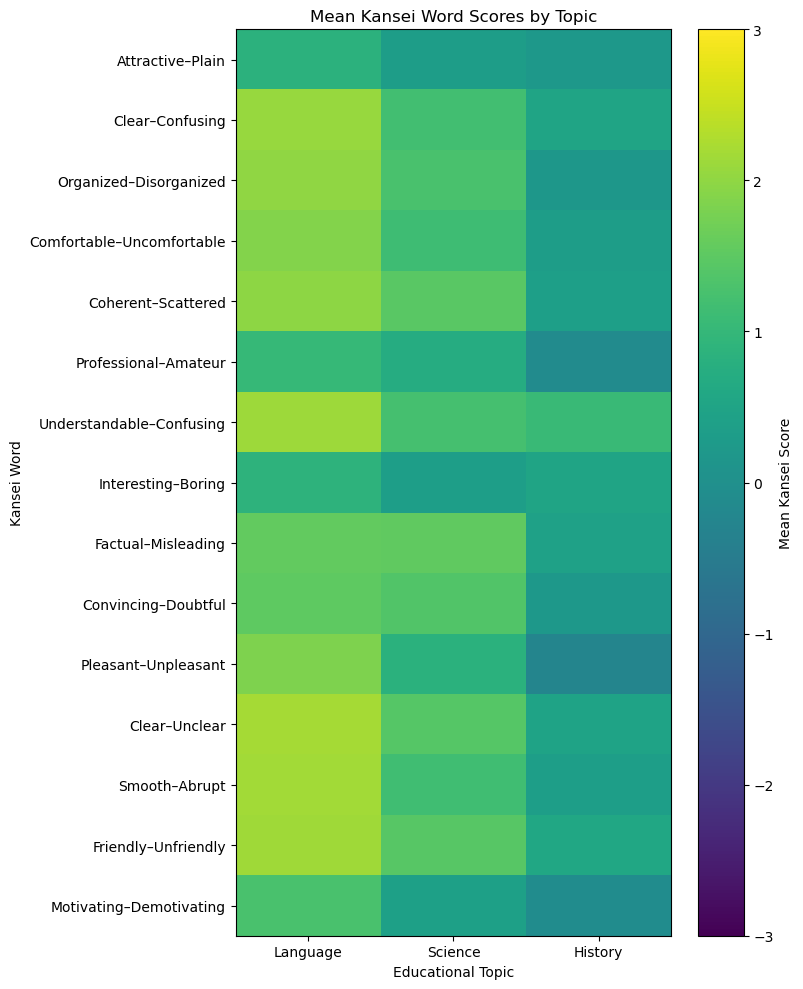

In [67]:
heatmap_data = (
    topic_word_means_readable.T
)

plt.figure(figsize=(8, 10))

image = plt.imshow(
    heatmap_data,
    aspect="auto",
    vmin=-3,
    vmax=3
)

plt.colorbar(
    image,
    label="Mean Kansei Score"
)

plt.xticks(
    ticks=range(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)

plt.yticks(
    ticks=range(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.xlabel("Educational Topic")
plt.ylabel("Kansei Word")
plt.title("Mean Kansei Word Scores by Topic")
plt.tight_layout()
plt.show()

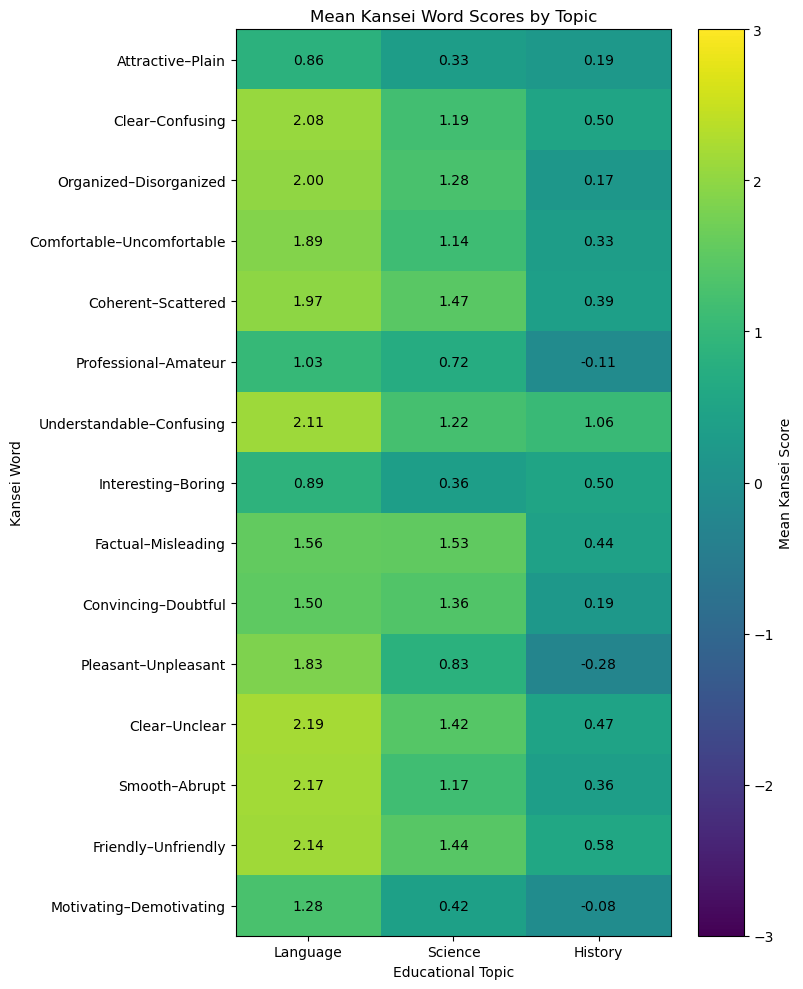

In [68]:
plt.figure(figsize=(8, 10))

image = plt.imshow(
    heatmap_data,
    aspect="auto",
    vmin=-3,
    vmax=3
)

plt.colorbar(
    image,
    label="Mean Kansei Score"
)

plt.xticks(
    ticks=range(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)

plt.yticks(
    ticks=range(len(heatmap_data.index)),
    labels=heatmap_data.index
)

for row in range(heatmap_data.shape[0]):
    for column in range(heatmap_data.shape[1]):

        value = heatmap_data.iloc[
            row,
            column
        ]

        plt.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

plt.xlabel("Educational Topic")
plt.ylabel("Kansei Word")
plt.title("Mean Kansei Word Scores by Topic")
plt.tight_layout()
plt.show()

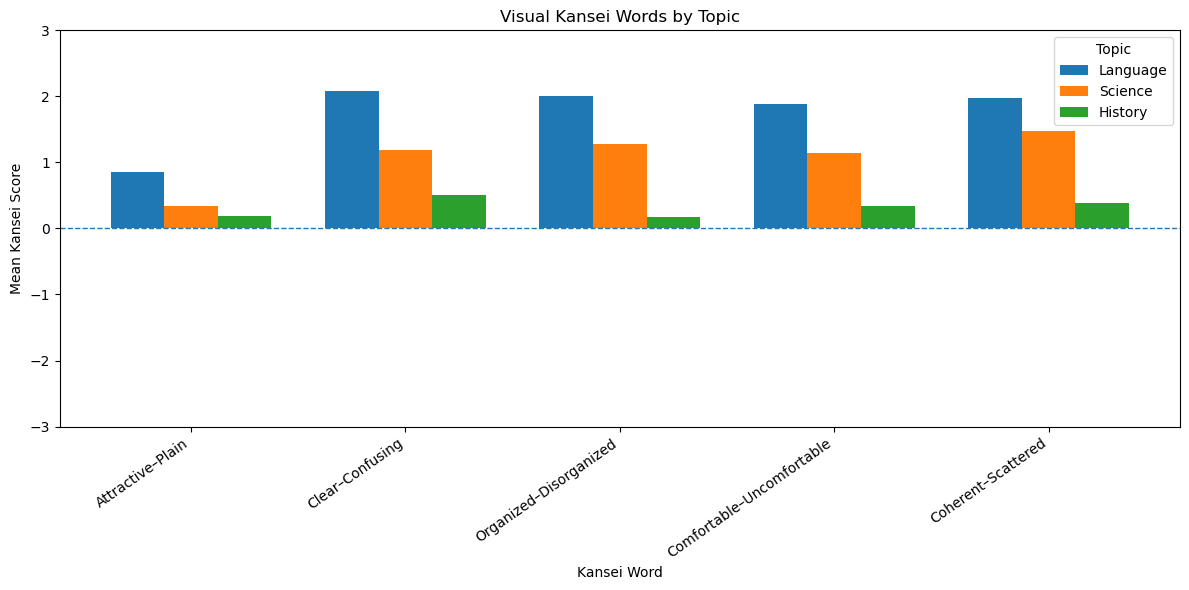

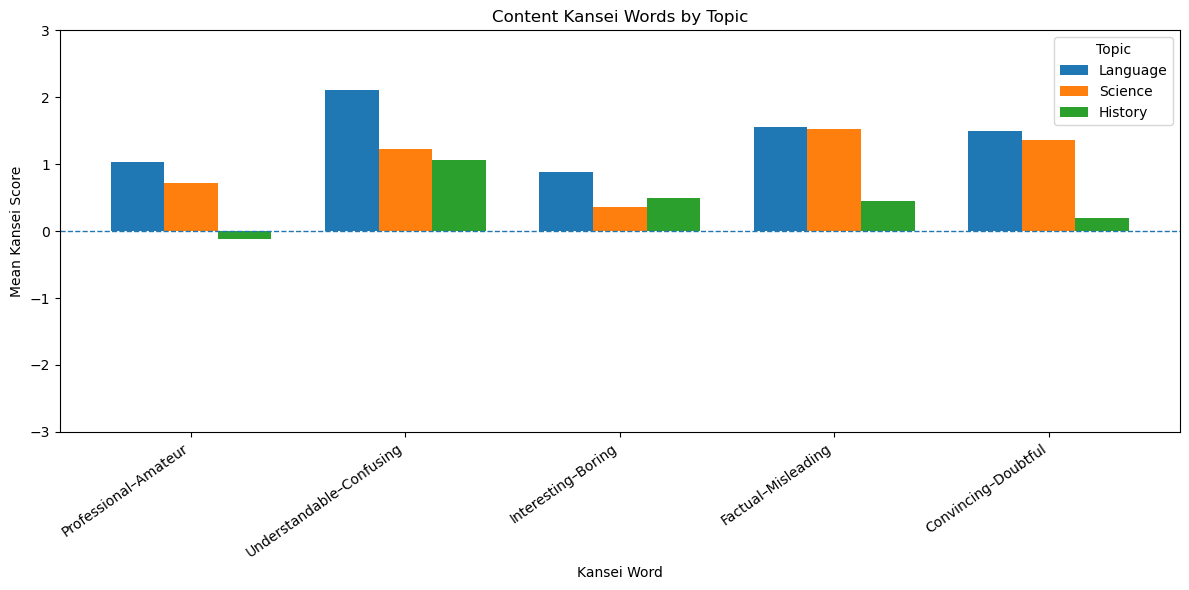

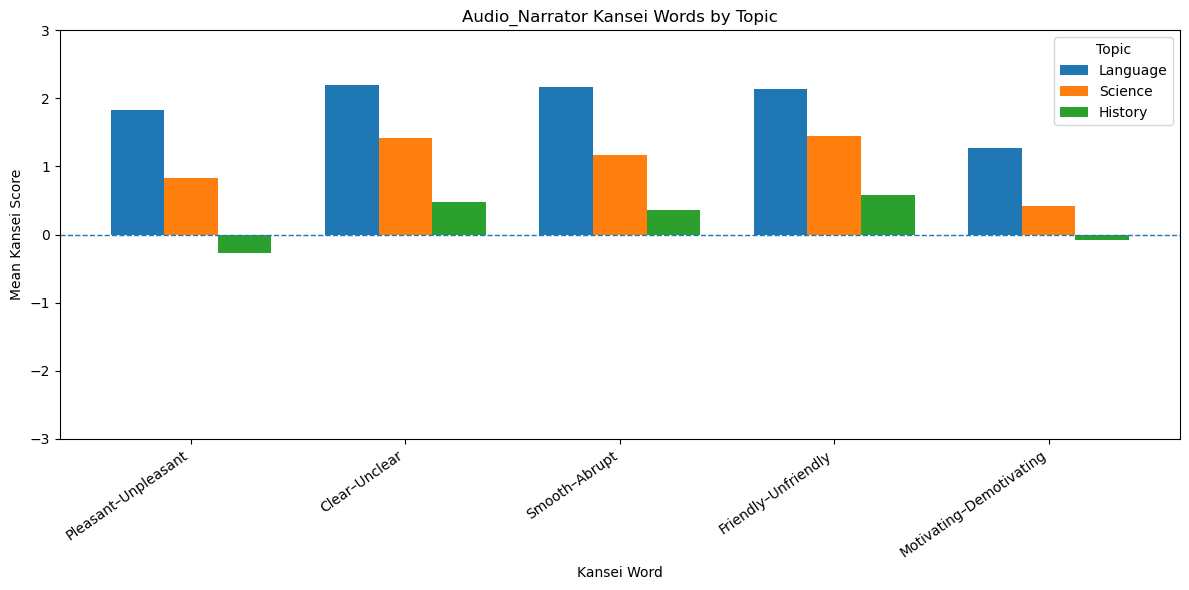

In [69]:
for dimension, columns in kansei_dimensions.items():

    readable_words = [
        kansei_labels[column]
        for column in columns
    ]

    x = np.arange(len(columns))
    bar_width = 0.25

    plt.figure(figsize=(12, 6))

    for topic_index, topic in enumerate(topic_order):

        topic_means = (
            df.loc[
                df["Topic"] == topic,
                columns
            ]
            .mean()
            .values
        )

        plt.bar(
            x + topic_index * bar_width,
            topic_means,
            width=bar_width,
            label=topic
        )

    plt.axhline(
        y=0,
        linestyle="--",
        linewidth=1
    )

    plt.xticks(
        x + bar_width,
        readable_words,
        rotation=35,
        ha="right"
    )

    plt.xlabel("Kansei Word")
    plt.ylabel("Mean Kansei Score")
    plt.title(
        f"{dimension} Kansei Words by Topic"
    )
    plt.ylim(-3, 3)
    plt.legend(title="Topic")
    plt.tight_layout()
    plt.show()

### 2.4 Statistical Tests

In [70]:
overall_wide = (
    complete_participant_topic_scores
    .pivot(
        index="participant_id",
        columns="Topic",
        values="Overall_Kansei_Score"
    )
    .reindex(columns=topic_order)
    .dropna()
)

display(overall_wide.head().round(3))

Topic,Language,Science,History
participant_id,,,
P-20260709T052634Z-F27519,2.541,2.452,0.801
P-20260709T074312Z-5E8136,2.142,0.917,0.394
P-20260709T080130Z-F2AA8F,1.513,1.740,-0.287
P-20260709T084146Z-D81B07,2.599,-0.210,-0.522
P-20260710T060100Z-36E24D,1.611,1.462,1.269


In [71]:
normality_results = []

for topic in topic_order:
    values = overall_wide[topic].dropna()

    if len(values) >= 3:
        statistic, p_value = stats.shapiro(
            values
        )
    else:
        statistic = np.nan
        p_value = np.nan

    normality_results.append({
        "Topic": topic,
        "N": len(values),
        "Shapiro W": statistic,
        "p-value": p_value,
        "Normal at 0.05":
            p_value > 0.05
            if not pd.isna(p_value)
            else np.nan
    })

normality_results = pd.DataFrame(
    normality_results
)

display(normality_results.round(4))

,Topic,N,Shapiro W,p-value,Normal at 0.05
0,Language,9,0.9118,0.3290,True
1,Science,9,0.9418,0.6010,True
2,History,9,0.9777,0.9516,True


In [72]:
anova_overall_data = (
    complete_participant_topic_scores[
        [
            "participant_id",
            "Topic",
            "Overall_Kansei_Score"
        ]
    ]
    .dropna()
)

overall_rm_anova = AnovaRM(
    data=anova_overall_data,
    depvar="Overall_Kansei_Score",
    subject="participant_id",
    within=["Topic"]
).fit()

print(overall_rm_anova)

               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
Topic 12.2189 2.0000 16.0000 0.0006



In [73]:
friedman_statistic, friedman_p = (
    stats.friedmanchisquare(
        overall_wide["Language"],
        overall_wide["Science"],
        overall_wide["History"]
    )
)

friedman_overall_result = pd.DataFrame({
    "Test": ["Friedman"],
    "Statistic": [friedman_statistic],
    "p-value": [friedman_p],
    "Significant": [friedman_p < 0.05]
})

display(friedman_overall_result.round(4))

,Test,Statistic,p-value,Significant
0,Friedman,12.6667,0.0018,True


In [74]:
pairwise_overall_results = []

topic_pairs = list(
    combinations(topic_order, 2)
)

for topic_1, topic_2 in topic_pairs:

    paired_data = overall_wide[
        [topic_1, topic_2]
    ].dropna()

    t_statistic, raw_p = stats.ttest_rel(
        paired_data[topic_1],
        paired_data[topic_2]
    )

    difference = (
        paired_data[topic_1] -
        paired_data[topic_2]
    )

    mean_difference = difference.mean()

    difference_sd = difference.std(ddof=1)

    if difference_sd == 0:
        cohens_dz = np.nan
    else:
        cohens_dz = (
            mean_difference /
            difference_sd
        )

    pairwise_overall_results.append({
        "Topic 1": topic_1,
        "Topic 2": topic_2,
        "N": len(paired_data),
        "Mean Difference":
            mean_difference,
        "t": t_statistic,
        "Raw p-value": raw_p,
        "Cohen dz": cohens_dz
    })

pairwise_overall_results = pd.DataFrame(
    pairwise_overall_results
)

In [75]:
reject, adjusted_p, _, _ = multipletests(
    pairwise_overall_results[
        "Raw p-value"
    ],
    alpha=0.05,
    method="holm"
)

pairwise_overall_results[
    "Adjusted p-value"
] = adjusted_p

pairwise_overall_results[
    "Significant"
] = reject

display(
    pairwise_overall_results.round(4)
)

,Topic 1,Topic 2,N,Mean Difference,t,Raw p-value,Cohen dz,Adjusted p-value,Significant
0,Language,Science,9,0.6432,2.0335,0.0764,0.6778,0.0764,False
1,Language,History,9,1.3828,4.7994,0.0014,1.5998,0.0041,True
2,Science,History,9,0.7396,3.2419,0.0118,1.0806,0.0237,True


In [76]:
wilcoxon_overall_results = []

for topic_1, topic_2 in topic_pairs:

    paired_data = overall_wide[
        [topic_1, topic_2]
    ].dropna()

    differences = (
        paired_data[topic_1] -
        paired_data[topic_2]
    )

    if np.allclose(differences, 0):
        statistic = 0
        raw_p = 1.0
    else:
        statistic, raw_p = (
            stats.wilcoxon(
                paired_data[topic_1],
                paired_data[topic_2]
            )
        )

    wilcoxon_overall_results.append({
        "Topic 1": topic_1,
        "Topic 2": topic_2,
        "N": len(paired_data),
        "Median Difference":
            differences.median(),
        "Wilcoxon Statistic":
            statistic,
        "Raw p-value":
            raw_p
    })

wilcoxon_overall_results = pd.DataFrame(
    wilcoxon_overall_results
)

In [77]:
reject, adjusted_p, _, _ = multipletests(
    wilcoxon_overall_results[
        "Raw p-value"
    ],
    alpha=0.05,
    method="holm"
)

wilcoxon_overall_results[
    "Adjusted p-value"
] = adjusted_p

wilcoxon_overall_results[
    "Significant"
] = reject

display(
    wilcoxon_overall_results.round(4)
)

,Topic 1,Topic 2,N,Median Difference,Wilcoxon Statistic,Raw p-value,Adjusted p-value,Significant
0,Language,Science,9,0.2429,6.0,0.0547,0.0547,False
1,Language,History,9,1.5525,0.0,0.0039,0.0117,True
2,Science,History,9,0.5227,1.0,0.0078,0.0156,True


In [78]:
def repeated_measures_anova_for_score(
    participant_topic_dataframe,
    score_column
):
    """
    Run repeated-measures ANOVA using one mean
    score per participant per topic.
    """

    relevant_data = (
        participant_topic_dataframe[
            [
                "participant_id",
                "Topic",
                score_column
            ]
        ]
        .dropna()
    )

    topic_counts = (
        relevant_data
        .groupby("participant_id")["Topic"]
        .nunique()
    )

    complete_ids = topic_counts[
        topic_counts == len(topic_order)
    ].index

    relevant_data = relevant_data[
        relevant_data["participant_id"].isin(
            complete_ids
        )
    ]

    if len(complete_ids) < 2:
        return None

    result = AnovaRM(
        data=relevant_data,
        depvar=score_column,
        subject="participant_id",
        within=["Topic"]
    ).fit()

    return result

In [79]:
scores_for_topic_tests = [
    "Overall_Kansei_Score",
    "Visual_Kansei_Score",
    "Content_Kansei_Score",
    "Audio_Narrator_Kansei_Score"
]

for score in scores_for_topic_tests:
    print("\n" + "=" * 60)
    print(score)
    print("=" * 60)

    result = repeated_measures_anova_for_score(
        participant_topic_scores,
        score
    )

    if result is None:
        print(
            "Not enough complete participants."
        )
    else:
        print(result)


Overall_Kansei_Score
               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
Topic 12.2189 2.0000 16.0000 0.0006


Visual_Kansei_Score
               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
Topic 16.3799 2.0000 16.0000 0.0001


Content_Kansei_Score
               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
Topic  4.3691 2.0000 16.0000 0.0306


Audio_Narrator_Kansei_Score
               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
Topic 14.1535 2.0000 16.0000 0.0003



In [83]:
mixed_model_data = df[
    [
        "participant_id",
        "Topic",
        "Overall_Kansei_Score"
    ]
].dropna().copy()

mixed_model_data["Topic"] = (
    mixed_model_data["Topic"]
    .cat.reorder_categories(
        topic_order,
        ordered=True
    )
)

overall_mixed_model = smf.mixedlm(
    formula=(
        "Overall_Kansei_Score "
        "~ C(Topic, Treatment(reference='Language'))"
    ),
    data=mixed_model_data,
    groups=mixed_model_data["participant_id"]
)

overall_mixed_result = (
    overall_mixed_model.fit(
        reml=False,
        method="lbfgs"
    )
)

print(overall_mixed_result.summary())

                             Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          Overall_Kansei_Score
No. Observations:            108              Method:                      ML                  
No. Groups:                  9                Scale:                       1.4360              
Min. group size:             12               Log-Likelihood:              -180.0212           
Max. group size:             12               Converged:                   Yes                 
Mean group size:             12.0                                                              
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                                             1.687    0.305 

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


In [84]:
science_reference_model = smf.mixedlm(
    formula=(
        "Overall_Kansei_Score "
        "~ C(Topic, Treatment(reference='Science'))"
    ),
    data=mixed_model_data,
    groups=mixed_model_data["participant_id"]
).fit(
    reml=False,
    method="lbfgs"
)

print(science_reference_model.summary())

                             Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          Overall_Kansei_Score
No. Observations:            108              Method:                      ML                  
No. Groups:                  9                Scale:                       1.4360              
Min. group size:             12               Log-Likelihood:              -180.0212           
Max. group size:             12               Converged:                   Yes                 
Mean group size:             12.0                                                              
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                                             1.043    0.305 

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


In [85]:
mixed_model_results = {}

for score_column in scores_for_topic_tests:

    model_data = df[
        [
            "participant_id",
            "Topic",
            score_column
        ]
    ].dropna().copy()

    model = smf.mixedlm(
        formula=(
            f"{score_column} "
            "~ C(Topic, Treatment(reference='Language'))"
        ),
        data=model_data,
        groups=model_data["participant_id"]
    )

    try:
        result = model.fit(
            reml=False,
            method="lbfgs"
        )

        mixed_model_results[
            score_column
        ] = result

        print("\n" + "=" * 70)
        print(score_column)
        print("=" * 70)
        print(result.summary())

    except Exception as error:
        print(
            f"Model failed for {score_column}:",
            error
        )

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)



Overall_Kansei_Score
                             Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          Overall_Kansei_Score
No. Observations:            108              Method:                      ML                  
No. Groups:                  9                Scale:                       1.4360              
Min. group size:             12               Log-Likelihood:              -180.0212           
Max. group size:             12               Converged:                   Yes                 
Mean group size:             12.0                                                              
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                                      

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 4.661393
  warnings.warn(msg, ConvergenceWarning)



Visual_Kansei_Score
                             Mixed Linear Model Regression Results
Model:                      MixedLM           Dependent Variable:           Visual_Kansei_Score
No. Observations:           108               Method:                       ML                 
No. Groups:                 9                 Scale:                        1.4973             
Min. group size:            12                Log-Likelihood:               -184.0803          
Max. group size:            12                Converged:                    No                 
Mean group size:            12.0                                                               
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                                       

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)



Content_Kansei_Score
                             Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          Content_Kansei_Score
No. Observations:            108              Method:                      ML                  
No. Groups:                  9                Scale:                       1.7900              
Min. group size:             12               Log-Likelihood:              -192.8978           
Max. group size:             12               Converged:                   No                  
Mean group size:             12.0                                                              
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                                      

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 3.659951
  warnings.warn(msg, ConvergenceWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


In [86]:
word_test_results = []

for column in kansei_columns:

    participant_word_topic = (
        df.groupby(
            ["participant_id", "Topic"],
            observed=False
        )[column]
        .mean()
        .reset_index()
    )

    word_wide = (
        participant_word_topic
        .pivot(
            index="participant_id",
            columns="Topic",
            values=column
        )
        .reindex(columns=topic_order)
        .dropna()
    )

    if len(word_wide) < 3:
        test_statistic = np.nan
        raw_p = np.nan
    else:
        test_statistic, raw_p = (
            stats.friedmanchisquare(
                word_wide["Language"],
                word_wide["Science"],
                word_wide["History"]
            )
        )

    word_test_results.append({
        "Dimension":
            column_to_dimension[column],
        "Column": column,
        "Kansei Word":
            kansei_labels[column],
        "N Participants":
            len(word_wide),
        "Friedman Statistic":
            test_statistic,
        "Raw p-value":
            raw_p
    })

word_test_results = pd.DataFrame(
    word_test_results
)

In [87]:
valid_mask = word_test_results[
    "Raw p-value"
].notna()

adjusted_values = np.full(
    len(word_test_results),
    np.nan
)

significance_values = np.full(
    len(word_test_results),
    False,
    dtype=bool
)

if valid_mask.sum() > 0:

    reject, adjusted_p, _, _ = multipletests(
        word_test_results.loc[
            valid_mask,
            "Raw p-value"
        ],
        alpha=0.05,
        method="fdr_bh"
    )

    adjusted_values[valid_mask] = adjusted_p
    significance_values[valid_mask] = reject

word_test_results[
    "FDR Adjusted p-value"
] = adjusted_values

word_test_results[
    "Significant after FDR"
] = significance_values

word_test_results = (
    word_test_results
    .sort_values(
        "FDR Adjusted p-value"
    )
)

display(word_test_results.round(4))

,Dimension,Column,Kansei Word,N Participants,Friedman Statistic,Raw p-value,FDR Adjusted p-value,Significant after FDR
2,Visual,organized_disorganized,Organized–Disorganized,9,14.8889,0.0006,0.0029,True
11,Audio_Narrator,clear_unclear,Clear–Unclear,9,15.9355,0.0003,0.0029,True
12,Audio_Narrator,smooth_abrupt,Smooth–Abrupt,9,15.0588,0.0005,0.0029,True
1,Visual,clear_confusing,Clear–Confusing,9,14.2500,0.0008,0.0030,True
10,Audio_Narrator,pleasant_unpleasant,Pleasant–Unpleasant,9,13.2353,0.0013,0.0040,True
4,Visual,coherent_scattered,Coherent–Scattered,9,11.8788,0.0026,0.0066,True
8,Content,factual_misleading,Factual–Misleading,9,10.9032,0.0043,0.0092,True
3,Visual,comfortable_uncomfortable,Comfortable–Uncomfortable,9,9.9412,0.0069,0.0130,True
6,Content,understandable_confusing,Understandable–Confusing,9,9.4545,0.0089,0.0148,True
13,Audio_Narrator,friendly_unfriendly,Friendly–Unfriendly,9,9.1875,0.0101,0.0152,True


In [88]:
significant_words = (
    word_test_results.loc[
        word_test_results[
            "Significant after FDR"
        ],
        "Column"
    ]
    .tolist()
)

print("Significant Kansei words:")
print(significant_words)

Significant Kansei words:
['organized_disorganized', 'clear_unclear', 'smooth_abrupt', 'clear_confusing', 'pleasant_unpleasant', 'coherent_scattered', 'factual_misleading', 'comfortable_uncomfortable', 'understandable_confusing', 'friendly_unfriendly', 'convincing_doubtful']


In [89]:
word_pairwise_results = []

for column in significant_words:

    participant_word_topic = (
        df.groupby(
            ["participant_id", "Topic"],
            observed=False
        )[column]
        .mean()
        .reset_index()
    )

    word_wide = (
        participant_word_topic
        .pivot(
            index="participant_id",
            columns="Topic",
            values=column
        )
        .reindex(columns=topic_order)
    )

    current_results = []

    for topic_1, topic_2 in topic_pairs:

        paired = word_wide[
            [topic_1, topic_2]
        ].dropna()

        differences = (
            paired[topic_1] -
            paired[topic_2]
        )

        if len(paired) == 0:
            statistic = np.nan
            raw_p = np.nan

        elif np.allclose(differences, 0):
            statistic = 0
            raw_p = 1.0

        else:
            statistic, raw_p = (
                stats.wilcoxon(
                    paired[topic_1],
                    paired[topic_2]
                )
            )

        current_results.append({
            "Column": column,
            "Kansei Word":
                kansei_labels[column],
            "Topic 1": topic_1,
            "Topic 2": topic_2,
            "N": len(paired),
            "Mean Topic 1":
                paired[topic_1].mean(),
            "Mean Topic 2":
                paired[topic_2].mean(),
            "Mean Difference":
                differences.mean(),
            "Wilcoxon Statistic":
                statistic,
            "Raw p-value":
                raw_p
        })

    current_results = pd.DataFrame(
        current_results
    )

    valid_pairwise = current_results[
        "Raw p-value"
    ].notna()

    adjusted = np.full(
        len(current_results),
        np.nan
    )

    rejected = np.full(
        len(current_results),
        False,
        dtype=bool
    )

    if valid_pairwise.sum() > 0:

        reject, adjusted_p, _, _ = (
            multipletests(
                current_results.loc[
                    valid_pairwise,
                    "Raw p-value"
                ],
                alpha=0.05,
                method="holm"
            )
        )

        adjusted[valid_pairwise] = (
            adjusted_p
        )

        rejected[valid_pairwise] = reject

    current_results[
        "Holm Adjusted p-value"
    ] = adjusted

    current_results[
        "Significant"
    ] = rejected

    word_pairwise_results.append(
        current_results
    )

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  tem

In [90]:
if word_pairwise_results:

    word_pairwise_results = pd.concat(
        word_pairwise_results,
        ignore_index=True
    )

    display(
        word_pairwise_results.round(4)
    )

else:
    word_pairwise_results = pd.DataFrame()

    print(
        "No Kansei words were significant "
        "after FDR correction."
    )

,Column,Kansei Word,Topic 1,Topic 2,N,Mean Topic 1,Mean Topic 2,Mean Difference,Wilcoxon Statistic,Raw p-value,Holm Adjusted p-value,Significant
0,organized_disorganized,Organized–Disorganized,Language,Science,9,2.0000,1.2778,0.7222,8.0,0.0977,0.0977,False
1,organized_disorganized,Organized–Disorganized,Language,History,9,2.0000,0.1667,1.8333,0.0,0.0039,0.0117,True
2,organized_disorganized,Organized–Disorganized,Science,History,9,1.2778,0.1667,1.1111,0.0,0.0039,0.0117,True
3,clear_unclear,Clear–Unclear,Language,Science,9,2.1944,1.4167,0.7778,0.0,0.0431,0.0431,True
4,clear_unclear,Clear–Unclear,Language,History,9,2.1944,0.4722,1.7222,0.0,0.0039,0.0117,True
5,clear_unclear,Clear–Unclear,Science,History,9,1.4167,0.4722,0.9444,0.0,0.0114,0.0228,True
6,smooth_abrupt,Smooth–Abrupt,Language,Science,9,2.1667,1.1667,1.0000,0.0,0.0180,0.0234,True
7,smooth_abrupt,Smooth–Abrupt,Language,History,9,2.1667,0.3611,1.8056,0.0,0.0039,0.0117,True
8,smooth_abrupt,Smooth–Abrupt,Science,History,9,1.1667,0.3611,0.8056,2.0,0.0117,0.0234,True
9,clear_confusing,Clear–Confusing,Language,Science,9,2.0833,1.1944,0.8889,0.0,0.0171,0.0343,True


### 2.5 Topic-Specific Kansei Characteristics

In [91]:
overall_word_means = (
    df[kansei_columns]
    .mean()
)

topic_word_deviation = (
    topic_word_means
    .subtract(
        overall_word_means,
        axis=1
    )
)

topic_word_deviation_readable = (
    topic_word_deviation
    .rename(columns=kansei_labels)
)

display(
    topic_word_deviation_readable.round(3)
)

,Attractive–Plain,Clear–Confusing,Organized–Disorganized,Comfortable–Uncomfortable,Coherent–Scattered,Professional–Amateur,Understandable–Confusing,Interesting–Boring,Factual–Misleading,Convincing–Doubtful,Pleasant–Unpleasant,Clear–Unclear,Smooth–Abrupt,Friendly–Unfriendly,Motivating–Demotivating
Topic,,,,,,,,,,,,,,,
Language,0.398,0.824,0.852,0.769,0.694,0.481,0.648,0.306,0.380,0.481,1.037,0.833,0.935,0.750,0.741
Science,-0.130,-0.065,0.130,0.019,0.194,0.176,-0.241,-0.222,0.352,0.343,0.037,0.056,-0.065,0.056,-0.120
History,-0.269,-0.759,-0.981,-0.787,-0.889,-0.657,-0.407,-0.083,-0.731,-0.824,-1.074,-0.889,-0.870,-0.806,-0.620


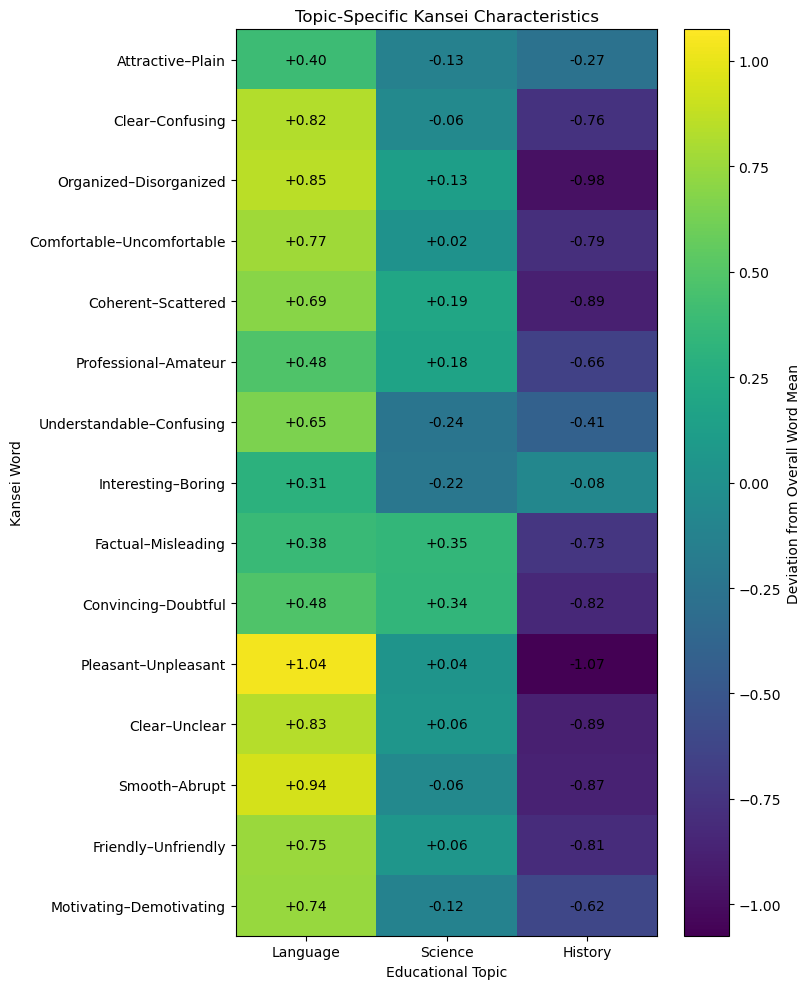

In [92]:
characteristic_heatmap = (
    topic_word_deviation_readable.T
)

maximum_absolute_value = (
    np.nanmax(
        np.abs(
            characteristic_heatmap.values
        )
    )
)

plt.figure(figsize=(8, 10))

image = plt.imshow(
    characteristic_heatmap,
    aspect="auto",
    vmin=-maximum_absolute_value,
    vmax=maximum_absolute_value
)

plt.colorbar(
    image,
    label="Deviation from Overall Word Mean"
)

plt.xticks(
    ticks=range(
        len(characteristic_heatmap.columns)
    ),
    labels=characteristic_heatmap.columns
)

plt.yticks(
    ticks=range(
        len(characteristic_heatmap.index)
    ),
    labels=characteristic_heatmap.index
)

for row in range(
    characteristic_heatmap.shape[0]
):
    for column in range(
        characteristic_heatmap.shape[1]
    ):

        value = characteristic_heatmap.iloc[
            row,
            column
        ]

        plt.text(
            column,
            row,
            f"{value:+.2f}",
            ha="center",
            va="center"
        )

plt.xlabel("Educational Topic")
plt.ylabel("Kansei Word")
plt.title("Topic-Specific Kansei Characteristics")
plt.tight_layout()
plt.show()

In [93]:
topic_characteristic_rows = []

for topic in topic_order:

    topic_deviations = (
        topic_word_deviation.loc[topic]
        .sort_values(
            ascending=False
        )
    )

    for rank, (
        column,
        deviation
    ) in enumerate(
        topic_deviations.items(),
        start=1
    ):

        topic_characteristic_rows.append({
            "Topic": topic,
            "Rank": rank,
            "Dimension":
                column_to_dimension[column],
            "Column": column,
            "Kansei Word":
                kansei_labels[column],
            "Topic Mean":
                topic_word_means.loc[
                    topic,
                    column
                ],
            "Overall Word Mean":
                overall_word_means[column],
            "Characteristic Deviation":
                deviation
        })

topic_characteristic_ranking = (
    pd.DataFrame(
        topic_characteristic_rows
    )
)

display(
    topic_characteristic_ranking.round(3)
)

,Topic,Rank,Dimension,Column,Kansei Word,Topic Mean,Overall Word Mean,Characteristic Deviation
0,Language,1,Audio_Narrator,pleasant_unpleasant,Pleasant–Unpleasant,1.833,0.796,1.037
1,Language,2,Audio_Narrator,smooth_abrupt,Smooth–Abrupt,2.167,1.231,0.935
2,Language,3,Visual,organized_disorganized,Organized–Disorganized,2.000,1.148,0.852
3,Language,4,Audio_Narrator,clear_unclear,Clear–Unclear,2.194,1.361,0.833
4,Language,5,Visual,clear_confusing,Clear–Confusing,2.083,1.259,0.824
5,Language,6,Visual,comfortable_uncomfortable,Comfortable–Uncomfortable,1.889,1.120,0.769
6,Language,7,Audio_Narrator,friendly_unfriendly,Friendly–Unfriendly,2.139,1.389,0.750
7,Language,8,Audio_Narrator,motivating_demotivating,Motivating–Demotivating,1.278,0.537,0.741
8,Language,9,Visual,coherent_scattered,Coherent–Scattered,1.972,1.278,0.694
9,Language,10,Content,understandable_confusing,Understandable–Confusing,2.111,1.463,0.648


In [94]:
top_characteristics = (
    topic_characteristic_ranking[
        topic_characteristic_ranking[
            "Rank"
        ] <= 5
    ]
)

display(
    top_characteristics[
        [
            "Topic",
            "Rank",
            "Dimension",
            "Kansei Word",
            "Topic Mean",
            "Characteristic Deviation"
        ]
    ].round(3)
)

,Topic,Rank,Dimension,Kansei Word,Topic Mean,Characteristic Deviation
0,Language,1,Audio_Narrator,Pleasant–Unpleasant,1.833,1.037
1,Language,2,Audio_Narrator,Smooth–Abrupt,2.167,0.935
2,Language,3,Visual,Organized–Disorganized,2.000,0.852
3,Language,4,Audio_Narrator,Clear–Unclear,2.194,0.833
4,Language,5,Visual,Clear–Confusing,2.083,0.824
15,Science,1,Content,Factual–Misleading,1.528,0.352
16,Science,2,Content,Convincing–Doubtful,1.361,0.343
17,Science,3,Visual,Coherent–Scattered,1.472,0.194
18,Science,4,Content,Professional–Amateur,0.722,0.176
19,Science,5,Visual,Organized–Disorganized,1.278,0.130


In [95]:
for topic in topic_order:

    print("\n" + "=" * 60)
    print(f"{topic}: strongest characteristics")
    print("=" * 60)

    topic_top = (
        top_characteristics[
            top_characteristics[
                "Topic"
            ] == topic
        ]
        [
            [
                "Rank",
                "Dimension",
                "Kansei Word",
                "Topic Mean",
                "Characteristic Deviation"
            ]
        ]
    )

    display(topic_top.round(3))


Language: strongest characteristics


,Rank,Dimension,Kansei Word,Topic Mean,Characteristic Deviation
0,1,Audio_Narrator,Pleasant–Unpleasant,1.833,1.037
1,2,Audio_Narrator,Smooth–Abrupt,2.167,0.935
2,3,Visual,Organized–Disorganized,2.000,0.852
3,4,Audio_Narrator,Clear–Unclear,2.194,0.833
4,5,Visual,Clear–Confusing,2.083,0.824



Science: strongest characteristics


,Rank,Dimension,Kansei Word,Topic Mean,Characteristic Deviation
15,1,Content,Factual–Misleading,1.528,0.352
16,2,Content,Convincing–Doubtful,1.361,0.343
17,3,Visual,Coherent–Scattered,1.472,0.194
18,4,Content,Professional–Amateur,0.722,0.176
19,5,Visual,Organized–Disorganized,1.278,0.130



History: strongest characteristics


,Rank,Dimension,Kansei Word,Topic Mean,Characteristic Deviation
30,1,Content,Interesting–Boring,0.500,-0.083
31,2,Visual,Attractive–Plain,0.194,-0.269
32,3,Content,Understandable–Confusing,1.056,-0.407
33,4,Audio_Narrator,Motivating–Demotivating,-0.083,-0.620
34,5,Content,Professional–Amateur,-0.111,-0.657


In [96]:
weakest_characteristics = (
    topic_characteristic_ranking
    .sort_values(
        [
            "Topic",
            "Characteristic Deviation"
        ],
        ascending=[
            True,
            True
        ]
    )
    .groupby(
        "Topic",
        observed=False
    )
    .head(5)
)

display(
    weakest_characteristics[
        [
            "Topic",
            "Dimension",
            "Kansei Word",
            "Topic Mean",
            "Characteristic Deviation"
        ]
    ].round(3)
)

,Topic,Dimension,Kansei Word,Topic Mean,Characteristic Deviation
44,History,Audio_Narrator,Pleasant–Unpleasant,-0.278,-1.074
43,History,Visual,Organized–Disorganized,0.167,-0.981
42,History,Audio_Narrator,Clear–Unclear,0.472,-0.889
41,History,Visual,Coherent–Scattered,0.389,-0.889
40,History,Audio_Narrator,Smooth–Abrupt,0.361,-0.870
14,Language,Content,Interesting–Boring,0.889,0.306
13,Language,Content,Factual–Misleading,1.556,0.380
12,Language,Visual,Attractive–Plain,0.861,0.398
10,Language,Content,Professional–Amateur,1.028,0.481
11,Language,Content,Convincing–Doubtful,1.500,0.481


In [97]:
topic_raw_profile_rows = []

for topic in topic_order:

    ranked_means = (
        topic_word_means.loc[topic]
        .sort_values(
            ascending=False
        )
    )

    for rank, (
        column,
        mean_score
    ) in enumerate(
        ranked_means.items(),
        start=1
    ):

        topic_raw_profile_rows.append({
            "Topic": topic,
            "Rank": rank,
            "Dimension":
                column_to_dimension[column],
            "Kansei Word":
                kansei_labels[column],
            "Mean Score":
                mean_score
        })

topic_raw_profiles = pd.DataFrame(
    topic_raw_profile_rows
)

display(
    topic_raw_profiles[
        topic_raw_profiles["Rank"] <= 5
    ].round(3)
)

,Topic,Rank,Dimension,Kansei Word,Mean Score
0,Language,1,Audio_Narrator,Clear–Unclear,2.194
1,Language,2,Audio_Narrator,Smooth–Abrupt,2.167
2,Language,3,Audio_Narrator,Friendly–Unfriendly,2.139
3,Language,4,Content,Understandable–Confusing,2.111
4,Language,5,Visual,Clear–Confusing,2.083
15,Science,1,Content,Factual–Misleading,1.528
16,Science,2,Visual,Coherent–Scattered,1.472
17,Science,3,Audio_Narrator,Friendly–Unfriendly,1.444
18,Science,4,Audio_Narrator,Clear–Unclear,1.417
19,Science,5,Content,Convincing–Doubtful,1.361


## 3. Popularity Analysis

In [100]:
videos = pd.read_csv("videos.csv")

In [101]:
print("Video data shape:", videos.shape)

print("\nVideo data columns:")
for index, column in enumerate(videos.columns):
    print(f"{index}: {column}")

display(videos.head())

Video data shape: (60, 12)

Video data columns:
0: title
1: topic
2: url
3: publish_date
4: likes
5: comments
6: shares
7: collections
8: views
9: subscribers
10: group
11: id


,title,topic,url,publish_date,likes,comments,shares,collections,views,subscribers,group,id
0,This powder changes color like magic,science,https://vt.tiktok.com/ZSxExR68v/,2022/4/19,4547000,27000,192000,196000,29177000,10546000,NaN,NaN
1,What if Time isn't real?,science,https://vt.tiktok.com/ZSxExMr85/,2026/5/2,580000,2738,59000,74000,2669000,11000,b,S01
2,Part 1: Earth Has Been Falling for 4.6 Billion...,science,https://vt.tiktok.com/ZSxExFVd4/,2026/2/28,472000,5395,24000,53000,4565000,546000,NaN,NaN
3,Today we look at some sound wave physics!,science,https://vt.tiktok.com/ZSxExj6M5/,2023/5/16,1086000,5562,44000,81000,12900000,385000,a,S02
4,Scientists discovery breaks a fundamental rule...,science,https://vt.tiktok.com/ZSxExFNAr/,2026/4/21,164000,939,24000,24000,1444000,40000,b,S02


In [102]:
videos = videos.rename(
    columns={
        "id": "video_id",
        "title": "original_video_title"
    }
)

In [103]:
videos["group"] = (
    videos["group"]
    .astype("string")
    .str.strip()
    .str.upper()
)

videos["video_id"] = (
    videos["video_id"]
    .astype("string")
    .str.strip()
    .str.upper()
)

In [104]:
experiment_videos = (
    videos
    .dropna(
        subset=[
            "group",
            "video_id"
        ]
    )
    .copy()
)

print(
    "Videos assigned to the experiment:",
    len(experiment_videos)
)

print("\nVideos by group:")
print(
    experiment_videos["group"]
    .value_counts()
    .sort_index()
)

Videos assigned to the experiment: 24

Videos by group:
group
A    12
B    12
Name: count, dtype: Int64


In [105]:
display(
    experiment_videos[
        [
            "group",
            "video_id",
            "original_video_title",
            "topic",
            "views",
            "likes",
            "comments",
            "shares",
            "collections",
            "subscribers",
            "publish_date"
        ]
    ]
    .sort_values(
        ["group", "video_id"]
    )
)

,group,video_id,original_video_title,topic,views,likes,comments,shares,collections,subscribers,publish_date
20,A,H01,Facts about the history of Japan you definitel...,history,3530000,722000,2155,25000,77000,407000,2024/5/2
23,A,H02,history of country of the world,history,12348000,1264000,8719,5139,112000,65000,2023/10/1
33,A,H03,The Earth spent 300 million years making oil.,history,1972000,54000,1649,3088,4545,3669,2026/3/23
38,A,H04,History of Japan,history,30000,650,5,41,111,24000,2026/2/4
40,A,L01,Do you know these irrregular verds and their f...,language,15620000,1568000,3571,23000,214000,5100000,2023/5/28
43,A,L02,Sports vocabulary,language,22023000,1820000,2957,16000,234000,4993000,2023/3/24
56,A,L03,"Can you pronounce these words> First you try, ...",language,24000,1358,21,49,390,120000,2026/5/26
55,A,L04,Have you ever actually practiced for an interview,language,39000,2754,21,240,623,83000,2026/5/5
5,A,S01,Power of Physics,science,49481000,1684000,12000,22000,54000,27000,2026/4/12
3,A,S02,Today we look at some sound wave physics!,science,12900000,1086000,5562,44000,81000,385000,2023/5/16


In [106]:
duplicate_video_keys = (
    experiment_videos
    .duplicated(
        subset=[
            "group",
            "video_id"
        ],
        keep=False
    )
)

if duplicate_video_keys.any():
    print(
        "Warning: duplicated group and video_id combinations were found."
    )

    display(
        experiment_videos.loc[
            duplicate_video_keys
        ].sort_values(
            ["group", "video_id"]
        )
    )
else:
    print(
        "Each group and video_id combination is unique."
    )

Each group and video_id combination is unique.


In [108]:
number_of_selected_videos = (
    experiment_videos[
        ["group", "video_id"]
    ]
    .drop_duplicates()
    .shape[0]
)

print(
    "Number of unique experiment videos:",
    number_of_selected_videos
)

Number of unique experiment videos: 24


In [110]:
popularity_raw_columns = [
    "likes",
    "comments",
    "shares",
    "collections",
    "views",
    "subscribers"
]

for column in popularity_raw_columns:
    experiment_videos[column] = pd.to_numeric(
        experiment_videos[column],
        errors="coerce"
    )

display(
    experiment_videos[
        popularity_raw_columns
    ]
    .isna()
    .sum()
    .to_frame("Missing Values")
)

,Missing Values
likes,0
comments,0
shares,0
collections,0
views,0
subscribers,0


In [111]:
for column in ["views", "subscribers"]:
    invalid_count = (
        experiment_videos[column] <= 0
    ).sum()

    print(
        f"{column}: {invalid_count} "
        "zero or negative values"
    )

views: 0 zero or negative values
subscribers: 0 zero or negative values


In [133]:
experiment_videos["engagement_count"] = (
    experiment_videos["likes"].fillna(0)
    + experiment_videos["comments"].fillna(0)
    + experiment_videos["shares"].fillna(0)
    + experiment_videos["collections"].fillna(0)
)

experiment_videos["ER"] = np.where(
    experiment_videos["views"] > 0,
    experiment_videos["engagement_count"]
    / experiment_videos["views"],
    np.nan
)

experiment_videos["publish_date"] = pd.to_datetime(
    experiment_videos["publish_date"],
    errors="coerce"
)

data_collection_date = pd.Timestamp("2026-07-16")

experiment_videos["age_days"] = (
    data_collection_date
    - experiment_videos["publish_date"]
).dt.days

invalid_age_rows = experiment_videos[
    experiment_videos["age_days"] <= 0
]

if invalid_age_rows.empty:
    print("All video ages are valid.")
else:
    print("Warning: videos with zero or negative age:")
    display(
        invalid_age_rows[
            [
                "original_video_title",
                "publish_date",
                "age_days"
            ]
        ]
    )

experiment_videos["TP"] = np.where(
    experiment_videos["age_days"] > 0,
    experiment_videos["views"]
    / np.log1p(experiment_videos["age_days"]+1),
    np.nan
)

All video ages are valid.


#### Popularity Score

In [134]:
scaler = StandardScaler()

experiment_videos[["ER_z", "TP_z"]] = scaler.fit_transform(
    experiment_videos[["ER", "TP"]]
)

In [135]:
display(
    experiment_videos[
        [
            "group",
            "video_id",
            "original_video_title",
            "likes",
            "comments",
            "shares",
            "collections",
            "views",
            "age_days",
            "ER",
            "TP",
            "ER_z",
            "TP_z"
        ]
    ]
    .sort_values(["group", "video_id"])
    .round({
        "ER": 6,
        "TP": 2
    })
)

,group,video_id,original_video_title,likes,comments,shares,collections,views,age_days,ER,TP,ER_z,TP_z
20,A,H01,Facts about the history of Japan you definitel...,722000,2155,25000,77000,3530000,805,0.234038,527391.20,2.303168,-0.289293
23,A,H02,history of country of the world,1264000,8719,5139,112000,12348000,1019,0.112557,1782194.21,0.342579,0.272400
33,A,H03,The Earth spent 300 million years making oil.,54000,1649,3088,4545,1972000,115,0.032090,414096.59,-0.956085,-0.340008
38,A,H04,History of Japan,650,5,41,111,30000,162,0.026900,5882.51,-1.039851,-0.522739
40,A,L01,Do you know these irrregular verds and their f...,1568000,3571,23000,214000,15620000,1145,0.115786,2217205.16,0.394680,0.467127
43,A,L02,Sports vocabulary,1820000,2957,16000,234000,22023000,1210,0.094127,3101819.12,0.045129,0.863111
56,A,L03,"Can you pronounce these words> First you try, ...",1358,21,49,390,24000,51,0.075750,6044.90,-0.251457,-0.522666
55,A,L04,Have you ever actually practiced for an interview,2754,21,240,623,39000,72,0.093282,9061.20,0.031494,-0.521316
5,A,S01,Power of Physics,1684000,12000,22000,54000,49481000,95,0.035812,10816202.43,-0.896024,4.316338
3,A,S02,Today we look at some sound wave physics!,1086000,5562,44000,81000,12900000,1157,0.094307,1828409.35,0.048038,0.293088


In [136]:
video_kansei_scores = (
    video_kansei_scores.rename(
        columns={
            "Group": "group",
            "Original_Video_ID": "video_id",
            "Topic": "topic",
            "Video_Title": "video_title"
        }
    )
)

In [137]:
video_kansei_scores["group"] = (
    video_kansei_scores["group"]
    .astype("string")
    .str.strip()
    .str.upper()
)

video_kansei_scores["video_id"] = (
    video_kansei_scores["video_id"]
    .astype("string")
    .str.strip()
    .str.upper()
)

In [138]:
display(
    video_kansei_scores[
        [
            "group",
            "video_id",
            "video_id_count",
            "video_title",
            "topic"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["group", "video_id"]
    )
)

,group,video_id,video_id_count,video_title,topic
0,A,H01,V01,Video A01,History
1,A,H02,V02,Video A02,History
2,A,H03,V03,Video A03,History
3,A,H04,V04,Video A05,History
4,A,L01,V05,Video A09,Language Learning
5,A,L02,V06,Video A06,Language Learning
6,A,L03,V07,Video A06,Language Learning
7,A,L04,V08,Video A06,Language Learning
8,A,S01,V09,Video A04,Science
9,A,S02,V10,Video A07,Science


In [139]:
video_word_scores = (
    df.groupby(
        [
            "group",
            "video_id"
        ],
        dropna=False
    )[kansei_columns]
    .mean()
    .reset_index()
)

display(
    video_word_scores.head().round(3)
)

,group,video_id,attractive_plain,clear_confusing,organized_disorganized,comfortable_uncomfortable,coherent_scattered,professional_amateur,understandable_confusing,interesting_boring,factual_misleading,convincing_doubtful,pleasant_unpleasant,clear_unclear,smooth_abrupt,friendly_unfriendly,motivating_demotivating
0,A,H01,-0.8,-0.2,-0.4,-0.8,-0.4,-1.2,0.4,-0.4,-0.6,-1.0,-1.4,-0.8,-0.8,-0.4,-0.8
1,A,H02,-0.8,0.2,-1.0,-0.6,-0.4,-0.6,0.6,-1.4,0.4,-0.2,-2.0,-0.6,-1.6,-0.6,-0.4
2,A,H03,0.8,2.0,2.0,1.2,1.2,1.0,2.0,1.0,1.4,1.2,1.2,1.6,2.0,1.6,0.6
3,A,H04,0.0,0.0,-1.2,-0.6,-0.2,-0.2,1.2,0.8,0.4,0.0,-0.8,0.2,-0.6,0.2,-0.2
4,A,L01,1.4,2.2,2.4,2.4,2.6,2.0,2.6,1.4,2.2,2.4,1.8,2.2,2.0,2.2,1.8


In [140]:
video_kansei_full = (
    video_kansei_scores.merge(
        video_word_scores,
        on=[
            "group",
            "video_id"
        ],
        how="left",
        validate="one_to_one"
    )
)

print(
    "Rows in video-level Kansei data:",
    len(video_kansei_full)
)

Rows in video-level Kansei data: 24


In [142]:
popularity_columns_to_merge = [
    "group",
    "video_id",
    "original_video_title",
    "url",
    "publish_date",
    "likes",
    "comments",
    "shares",
    "collections",
    "views",
    "subscribers",
    "age_days",
    "engagement_count",
    "ER",
    "TP",
    "ER_z",
    "TP_z"
]

popularity_data = (
    experiment_videos[
        popularity_columns_to_merge
    ]
    .drop_duplicates(
        subset=[
            "group",
            "video_id"
        ]
    )
)

video_analysis = (
    video_kansei_full.merge(
        popularity_data,
        on=[
            "group",
            "video_id"
        ],
        how="left",
        validate="one_to_one"
    )
)

print(
    "Rows after merging:",
    len(video_analysis)
)

print(
    "Videos missing TP:",
    video_analysis["TP"].isna().sum()
)

Rows after merging: 24
Videos missing TP: 0


In [143]:
display(
    video_analysis[
        [
            "group",
            "video_id",
            "video_id_count",
            "video_title",
            "original_video_title",
            "topic",
            "Overall_Kansei_Mean",
            "ER",
            "TP",
            "ER_z",
            "TP_z"
        ]
    ]
    .sort_values(
        ["group", "video_id"]
    )
    .round(4)
)

,group,video_id,video_id_count,video_title,original_video_title,topic,Overall_Kansei_Mean,ER,TP,ER_z,TP_z
0,A,H01,V01,Video A01,Facts about the history of Japan you definitel...,History,-0.6536,0.2340,5.273912e+05,2.3032,-0.2893
1,A,H02,V02,Video A02,history of country of the world,History,-0.6274,0.1126,1.782194e+06,0.3426,0.2724
2,A,H03,V03,Video A03,The Earth spent 300 million years making oil.,History,1.3761,0.0321,4.140966e+05,-0.9561,-0.3400
3,A,H04,V04,Video A05,History of Japan,History,-0.0750,0.0269,5.882507e+03,-1.0399,-0.5227
4,A,L01,V05,Video A09,Do you know these irrregular verds and their f...,Language Learning,2.0917,0.1158,2.217205e+06,0.3947,0.4671
5,A,L02,V06,Video A06,Sports vocabulary,Language Learning,1.0210,0.0941,3.101819e+06,0.0451,0.8631
6,A,L03,V07,Video A06,"Can you pronounce these words> First you try, ...",Language Learning,1.9997,0.0758,6.044896e+03,-0.2515,-0.5227
7,A,L04,V08,Video A06,Have you ever actually practiced for an interview,Language Learning,0.7199,0.0933,9.061201e+03,0.0315,-0.5213
8,A,S01,V09,Video A04,Power of Physics,Science,-0.7119,0.0358,1.081620e+07,-0.8960,4.3163
9,A,S02,V10,Video A07,Today we look at some sound wave physics!,Science,2.1366,0.0943,1.828409e+06,0.0480,0.2931


In [145]:
popularity_metrics = ["ER_z", "TP_z"]

# Check that both columns exist
missing_metrics = [
    metric
    for metric in popularity_metrics
    if metric not in video_analysis.columns
]

if missing_metrics:
    print(
        "The following popularity columns are missing:",
        missing_metrics
    )
else:
    # A video is considered unmatched if both ER and TP are missing
    unmatched_videos = video_analysis[
        video_analysis[popularity_metrics]
        .isna()
        .all(axis=1)
    ]

    if unmatched_videos.empty:
        print(
            "All experiment videos were successfully "
            "matched with popularity data."
        )
    else:
        print(
            f"{len(unmatched_videos)} videos were not matched."
        )

        display(
            unmatched_videos[
                [
                    "group",
                    "video_id",
                    "video_id_count",
                    "video_title"
                ]
            ]
        )

All experiment videos were successfully matched with popularity data.


In [147]:
video_analysis_complete = (
    video_analysis
    .dropna(
        subset=[
            "Overall_Kansei_Mean",
            "ER",
            "TP"
        ]
    )
    .copy()
)

print(
    "Videos available for Popularity Analysis:",
    len(video_analysis_complete)
)

Videos available for Popularity Analysis: 24


In [148]:
print("\nVideos by group:")

print(
    video_analysis_complete[
        "group"
    ].value_counts().sort_index()
)


Videos by group:
group
A    12
B    12
Name: count, dtype: int64


In [150]:
print("\nVideos by topic:")

print(
    video_analysis_complete[
        "topic"
    ].value_counts()
)


Videos by topic:
topic
History              8
Language Learning    8
Science              8
Name: count, dtype: int64


In [164]:
video_analysis_complete["PS"] = (
    video_analysis_complete["ER_z"]
    + video_analysis_complete["TP_z"]
)

display(
    video_analysis_complete[
        [
            "group",
            "video_id",
            "video_id_count",
            "video_title",
            "ER",
            "ER_z",
            "TP",
            "TP_z",
            "PS"
        ]
    ]
    .sort_values(
        ["group", "video_id"]
    )
    .round(4)
)

,group,video_id,video_id_count,video_title,ER,ER_z,TP,TP_z,PS
0,A,H01,V01,Video A01,0.2340,2.3032,5.273912e+05,-0.2893,2.0139
1,A,H02,V02,Video A02,0.1126,0.3426,1.782194e+06,0.2724,0.6150
2,A,H03,V03,Video A03,0.0321,-0.9561,4.140966e+05,-0.3400,-1.2961
3,A,H04,V04,Video A05,0.0269,-1.0399,5.882507e+03,-0.5227,-1.5626
4,A,L01,V05,Video A09,0.1158,0.3947,2.217205e+06,0.4671,0.8618
5,A,L02,V06,Video A06,0.0941,0.0451,3.101819e+06,0.8631,0.9082
6,A,L03,V07,Video A06,0.0758,-0.2515,6.044896e+03,-0.5227,-0.7741
7,A,L04,V08,Video A06,0.0933,0.0315,9.061201e+03,-0.5213,-0.4898
8,A,S01,V09,Video A04,0.0358,-0.8960,1.081620e+07,4.3163,3.4203
9,A,S02,V10,Video A07,0.0943,0.0480,1.828409e+06,0.2931,0.3411


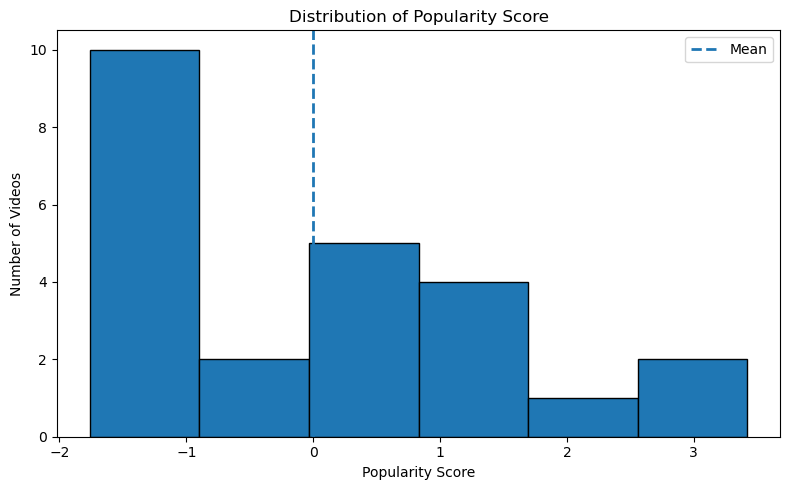

In [165]:
plt.figure(figsize=(8,5))

plt.hist(
    video_analysis_complete["PS"],
    bins="auto",
    edgecolor="black"
)

plt.axvline(
    x=video_analysis_complete["PS"].mean(),
    linestyle="--",
    linewidth=2,
    label="Mean"
)

plt.xlabel("Popularity Score")
plt.ylabel("Number of Videos")
plt.title("Distribution of Popularity Score")

plt.legend()

plt.tight_layout()
plt.show()

In [166]:
popularity_ranking = (
    video_analysis_complete
    .sort_values(
        "PS",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    popularity_ranking[
        [
            "group",
            "video_id_count",
            "video_title",
            "topic",
            "ER",
            "TP",
            "PS"
        ]
    ].round(4)
)

,group,video_id_count,video_title,topic,ER,TP,PS
0,A,V09,Video A04,science,0.0358,1.081620e+07,3.4203
1,B,V21,Video B04,science,0.2682,6.144382e+05,2.6036
2,A,V01,Video A01,history,0.2340,5.273912e+05,2.0139
3,B,V13,Video B01,history,0.1289,2.970523e+06,1.4106
4,B,V17,Video B09,language learning,0.1282,1.878871e+06,0.9107
5,A,V06,Video A06,language learning,0.0941,3.101819e+06,0.9082
6,A,V05,Video A09,language learning,0.1158,2.217205e+06,0.8618
7,A,V02,Video A02,history,0.1126,1.782194e+06,0.6150
8,B,V22,Video B07,science,0.1475,3.225132e+05,0.5249
9,B,V14,Video B02,history,0.1418,3.911051e+05,0.4649


### 3.1 Popularity Score Overview

In [167]:
popularity_summary = (
    video_analysis_complete[
        [
            "ER",
            "ER_z",
            "TP",
            "TP_z",
            "PS"
        ]
    ]
    .describe()
    .T
)

display(popularity_summary.round(4))

,count,mean,std,min,25%,50%,75%,max
ER,24.0,9.130000e-02,6.330000e-02,0.0147,0.0464,0.0845,1.189000e-01,2.682000e-01
ER_z,24.0,0.000000e+00,1.021500e+00,-1.2373,-0.7251,-0.1100,4.448000e-01,2.854000e+00
TP,24.0,1.173662e+06,2.282011e+06,351.3322,8307.1248,356809.1373,1.793748e+06,1.081620e+07
TP_z,24.0,-0.000000e+00,1.021500e+00,-0.5252,-0.5217,-0.3657,2.776000e-01,4.316300e+00
PS,24.0,-0.000000e+00,1.420400e+00,-1.7603,-1.1182,-0.1574,8.734000e-01,3.420300e+00


In [168]:
popularity_descriptive_rows = []

for column in [
    "ER",
    "TP",
    "ER_z",
    "TP_z",
    "PS"
]:

    values = (
        video_analysis_complete[column]
        .dropna()
    )

    popularity_descriptive_rows.append({
        "Popularity Measure": column,
        "N": len(values),
        "Mean": values.mean(),
        "SD": values.std(ddof=1),
        "Median": values.median(),
        "Minimum": values.min(),
        "Maximum": values.max(),
        "Skewness": values.skew()
    })

popularity_descriptive = pd.DataFrame(
    popularity_descriptive_rows
)

display(popularity_descriptive.round(4))

,Popularity Measure,N,Mean,SD,Median,Minimum,Maximum,Skewness
0,ER,24,9.130000e-02,6.330000e-02,0.0845,0.0147,2.682000e-01,1.3140
1,TP,24,1.173662e+06,2.282011e+06,356809.1373,351.3322,1.081620e+07,3.5615
2,ER_z,24,0.000000e+00,1.021500e+00,-0.1100,-1.2373,2.854000e+00,1.3140
3,TP_z,24,-0.000000e+00,1.021500e+00,-0.3657,-0.5252,4.316300e+00,3.5615
4,PS,24,-0.000000e+00,1.420400e+00,-0.1574,-1.7603,3.420300e+00,0.7579


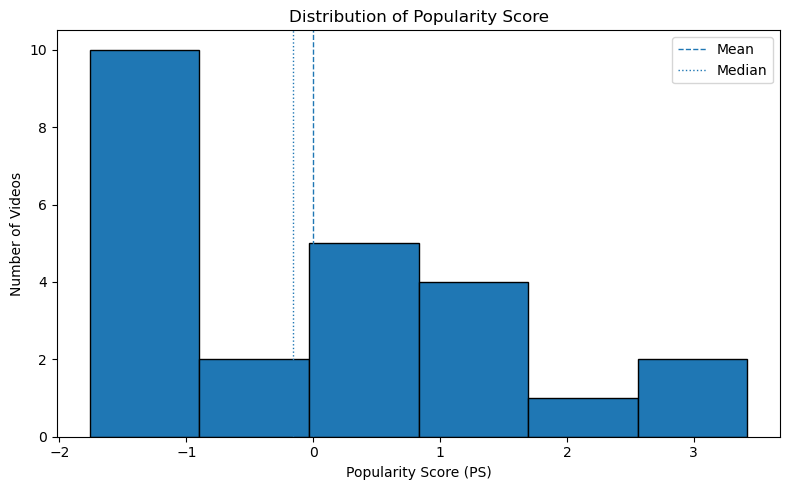

In [169]:
plt.figure(figsize=(8, 5))

plt.hist(
    video_analysis_complete["PS"],
    bins="auto",
    edgecolor="black"
)

plt.axvline(
    x=video_analysis_complete[
        "PS"
    ].mean(),
    linestyle="--",
    linewidth=1,
    label="Mean"
)

plt.axvline(
    x=video_analysis_complete[
        "PS"
    ].median(),
    linestyle=":",
    linewidth=1,
    label="Median"
)

plt.xlabel("Popularity Score (PS)")
plt.ylabel("Number of Videos")
plt.title("Distribution of Popularity Score")
plt.legend()
plt.tight_layout()
plt.show()

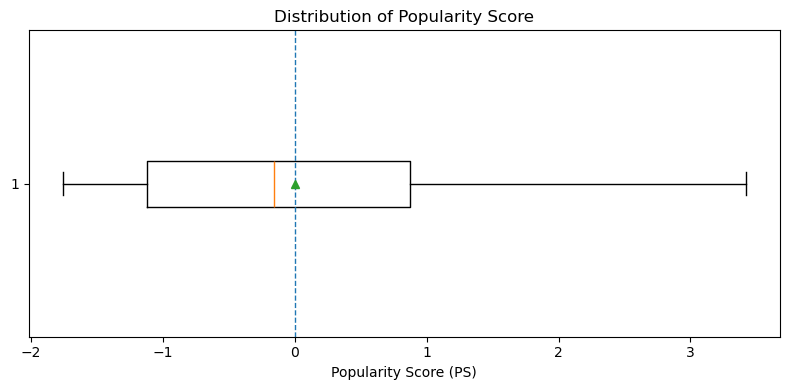

In [170]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    video_analysis_complete[
        "PS"
    ].dropna(),
    vert=False,
    showmeans=True
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Popularity Score (PS)")
plt.title("Distribution of Popularity Score")
plt.tight_layout()
plt.show()

In [171]:
popularity_ranking = (
    video_analysis_complete
    .sort_values(
        "PS",
        ascending=False
    )
    .reset_index(drop=True)
)

popularity_ranking[
    "Popularity_Rank"
] = (
    popularity_ranking.index + 1
)

ranking_columns = [
    "Popularity_Rank",
    "group",
    "video_id",
    "video_id_count",
    "video_title",
    "topic",
    "ER_z",
    "TP_z",
    "PS"
]

ranking_columns = [
    column
    for column in ranking_columns
    if column in popularity_ranking.columns
]

display(
    popularity_ranking[
        ranking_columns
    ].round(4)
)

,Popularity_Rank,group,video_id,video_id_count,video_title,topic,ER_z,TP_z,PS
0,1,A,S01,V09,Video A04,science,-0.8960,4.3163,3.4203
1,2,B,S01,V21,Video B04,science,2.8540,-0.2503,2.6036
2,3,A,H01,V01,Video A01,history,2.3032,-0.2893,2.0139
3,4,B,H01,V13,Video B01,history,0.6063,0.8043,1.4106
4,5,B,L01,V17,Video B09,language learning,0.5951,0.3157,0.9107
5,6,A,L02,V06,Video A06,language learning,0.0451,0.8631,0.9082
6,7,A,L01,V05,Video A09,language learning,0.3947,0.4671,0.8618
7,8,A,H02,V02,Video A02,history,0.3426,0.2724,0.6150
8,9,B,S02,V22,Video B07,science,0.9060,-0.3810,0.5249
9,10,B,H02,V14,Video B02,history,0.8152,-0.3503,0.4649


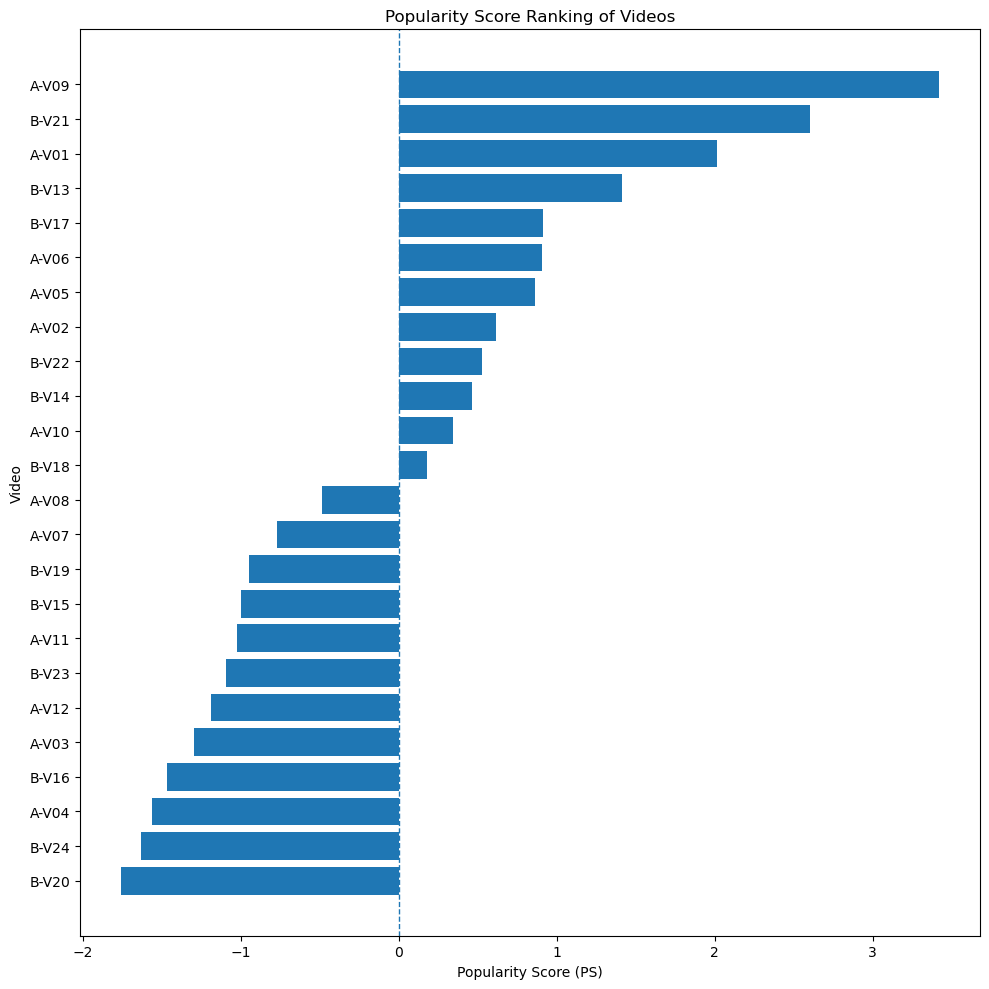

In [172]:
ranking_plot = (
    popularity_ranking
    .sort_values(
        "PS",
        ascending=True
    )
)

if "video_id_count" in ranking_plot.columns:
    video_labels = (
        ranking_plot["group"].astype(str)
        + "-"
        + ranking_plot[
            "video_id_count"
        ].astype(str)
    )
else:
    video_labels = (
        ranking_plot["group"].astype(str)
        + "-"
        + ranking_plot[
            "video_id"
        ].astype(str)
    )

plt.figure(figsize=(10, 10))

plt.barh(
    video_labels,
    ranking_plot["PS"]
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Popularity Score (PS)")
plt.ylabel("Video")
plt.title("Popularity Score Ranking of Videos")
plt.tight_layout()
plt.show()

In [173]:
if "Topic" not in video_analysis_complete.columns:

    video_analysis_complete[
        "topic"
    ] = (
        video_analysis_complete[
            "topic"
        ]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    topic_name_map = {
        "language": "Language",
        "language learning": "Language",
        "language_learning": "Language",
        "science": "Science",
        "history": "History"
    }

    video_analysis_complete[
        "Topic"
    ] = (
        video_analysis_complete[
            "topic"
        ].map(topic_name_map)
    )

In [174]:
topic_order = [
    "Language",
    "Science",
    "History"
]

video_analysis_complete[
    "Topic"
] = pd.Categorical(
    video_analysis_complete["Topic"],
    categories=topic_order,
    ordered=True
)

ps_topic_summary = (
    video_analysis_complete
    .groupby(
        "Topic",
        observed=False
    )["PS"]
    .agg(
        Mean="mean",
        SD="std",
        Median="median",
        Minimum="min",
        Maximum="max",
        N="count"
    )
    .reset_index()
)

ps_topic_summary["SE"] = (
    ps_topic_summary["SD"]
    / np.sqrt(
        ps_topic_summary["N"]
    )
)

display(ps_topic_summary.round(4))

,Topic,Mean,SD,Median,Minimum,Maximum,N,SE
0,Language,-0.1402,1.0083,-0.1574,-1.7603,0.9107,8,0.3565
1,Science,0.2432,1.8797,-0.3425,-1.6332,3.4203,8,0.6646
2,History,-0.1030,1.4060,-0.2666,-1.5626,2.0139,8,0.4971


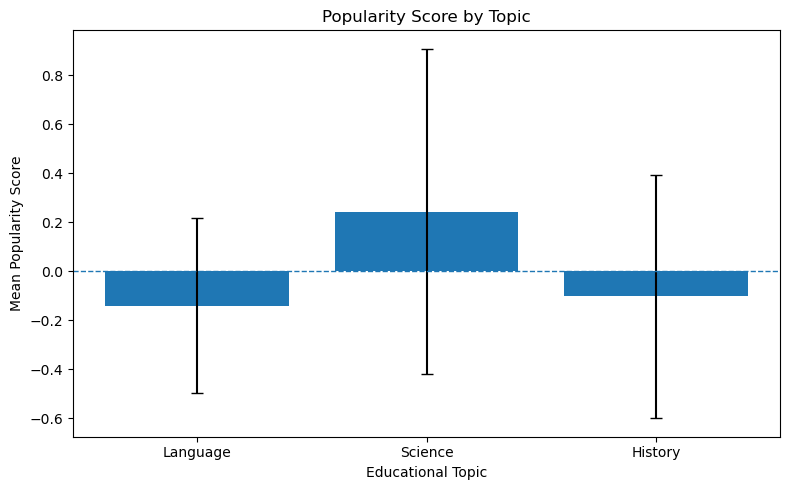

In [175]:
plot_topic_summary = (
    ps_topic_summary
    .set_index("Topic")
    .reindex(topic_order)
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    plot_topic_summary["Topic"],
    plot_topic_summary["Mean"],
    yerr=plot_topic_summary["SE"],
    capsize=4
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Educational Topic")
plt.ylabel("Mean Popularity Score")
plt.title("Popularity Score by Topic")
plt.tight_layout()
plt.show()

In [176]:
topic_ps_values = [
    video_analysis_complete.loc[
        video_analysis_complete[
            "Topic"
        ] == topic,
        "PS"
    ].dropna()
    for topic in topic_order
]

if all(
    len(values) > 0
    for values in topic_ps_values
):
    ps_topic_statistic, ps_topic_p = (
        stats.kruskal(
            *topic_ps_values
        )
    )

    ps_topic_test = pd.DataFrame({
        "Test": ["Kruskal-Wallis"],
        "Statistic": [
            ps_topic_statistic
        ],
        "p-value": [
            ps_topic_p
        ],
        "Significant": [
            ps_topic_p < 0.05
        ]
    })

    display(ps_topic_test.round(4))

,Test,Statistic,p-value,Significant
0,Kruskal-Wallis,0.08,0.9608,False


### 3.2 Relationship Between Kansei Score and Popularity

In [177]:
kansei_score_variables = {
    "Overall_Kansei_Mean":
        "Overall Kansei Score",

    "Visual_Kansei_Mean":
        "Visual Kansei Score",

    "Content_Kansei_Mean":
        "Content Kansei Score",

    "Audio_Narrator_Kansei_Mean":
        "Audio & Narrator Kansei Score"
}

In [178]:
missing_kansei_scores = [
    column
    for column in kansei_score_variables
    if column not in video_analysis_complete.columns
]

if missing_kansei_scores:
    raise ValueError(
        "The following Kansei Score columns "
        f"are missing: {missing_kansei_scores}"
    )

In [179]:
kansei_ps_results = []

for kansei_column, kansei_name in (
    kansei_score_variables.items()
):

    correlation_data = (
        video_analysis_complete[
            [
                kansei_column,
                "PS"
            ]
        ]
        .dropna()
    )

    n = len(correlation_data)

    if n >= 3:

        pearson_r, pearson_p = (
            stats.pearsonr(
                correlation_data[
                    kansei_column
                ],
                correlation_data["PS"]
            )
        )

        spearman_rho, spearman_p = (
            stats.spearmanr(
                correlation_data[
                    kansei_column
                ],
                correlation_data["PS"]
            )
        )

    else:
        pearson_r = np.nan
        pearson_p = np.nan
        spearman_rho = np.nan
        spearman_p = np.nan

    kansei_ps_results.append({
        "Kansei Measure": kansei_name,
        "Kansei Column": kansei_column,
        "N Videos": n,
        "Pearson r": pearson_r,
        "Pearson p-value": pearson_p,
        "Spearman rho": spearman_rho,
        "Spearman p-value": spearman_p
    })

kansei_ps_correlations = pd.DataFrame(
    kansei_ps_results
)

display(
    kansei_ps_correlations.round(4)
)

,Kansei Measure,Kansei Column,N Videos,Pearson r,Pearson p-value,Spearman rho,Spearman p-value
0,Overall Kansei Score,Overall_Kansei_Mean,24,-0.1394,0.5159,0.0009,0.9968
1,Visual Kansei Score,Visual_Kansei_Mean,24,-0.0932,0.6649,-0.0061,0.9775
2,Content Kansei Score,Content_Kansei_Mean,24,-0.1379,0.5206,-0.0070,0.9743
3,Audio & Narrator Kansei Score,Audio_Narrator_Kansei_Mean,24,-0.1660,0.4383,-0.0957,0.6566


In [180]:
valid_mask = (
    kansei_ps_correlations[
        "Spearman p-value"
    ].notna()
)

kansei_ps_correlations[
    "Adjusted p-value"
] = np.nan

kansei_ps_correlations[
    "Significant"
] = False

if valid_mask.sum() > 0:

    reject, adjusted_p, _, _ = (
        multipletests(
            kansei_ps_correlations.loc[
                valid_mask,
                "Spearman p-value"
            ],
            alpha=0.05,
            method="holm"
        )
    )

    kansei_ps_correlations.loc[
        valid_mask,
        "Adjusted p-value"
    ] = adjusted_p

    kansei_ps_correlations.loc[
        valid_mask,
        "Significant"
    ] = reject

display(
    kansei_ps_correlations.round(4)
)

,Kansei Measure,Kansei Column,N Videos,Pearson r,Pearson p-value,Spearman rho,Spearman p-value,Adjusted p-value,Significant
0,Overall Kansei Score,Overall_Kansei_Mean,24,-0.1394,0.5159,0.0009,0.9968,1.0,False
1,Visual Kansei Score,Visual_Kansei_Mean,24,-0.0932,0.6649,-0.0061,0.9775,1.0,False
2,Content Kansei Score,Content_Kansei_Mean,24,-0.1379,0.5206,-0.0070,0.9743,1.0,False
3,Audio & Narrator Kansei Score,Audio_Narrator_Kansei_Mean,24,-0.1660,0.4383,-0.0957,0.6566,1.0,False


In [181]:
valid_mask = (
    kansei_ps_correlations[
        "Spearman p-value"
    ].notna()
)

kansei_ps_correlations[
    "Adjusted p-value"
] = np.nan

kansei_ps_correlations[
    "Significant"
] = False

if valid_mask.sum() > 0:

    reject, adjusted_p, _, _ = (
        multipletests(
            kansei_ps_correlations.loc[
                valid_mask,
                "Spearman p-value"
            ],
            alpha=0.05,
            method="holm"
        )
    )

    kansei_ps_correlations.loc[
        valid_mask,
        "Adjusted p-value"
    ] = adjusted_p

    kansei_ps_correlations.loc[
        valid_mask,
        "Significant"
    ] = reject

display(
    kansei_ps_correlations.round(4)
)

,Kansei Measure,Kansei Column,N Videos,Pearson r,Pearson p-value,Spearman rho,Spearman p-value,Adjusted p-value,Significant
0,Overall Kansei Score,Overall_Kansei_Mean,24,-0.1394,0.5159,0.0009,0.9968,1.0,False
1,Visual Kansei Score,Visual_Kansei_Mean,24,-0.0932,0.6649,-0.0061,0.9775,1.0,False
2,Content Kansei Score,Content_Kansei_Mean,24,-0.1379,0.5206,-0.0070,0.9743,1.0,False
3,Audio & Narrator Kansei Score,Audio_Narrator_Kansei_Mean,24,-0.1660,0.4383,-0.0957,0.6566,1.0,False


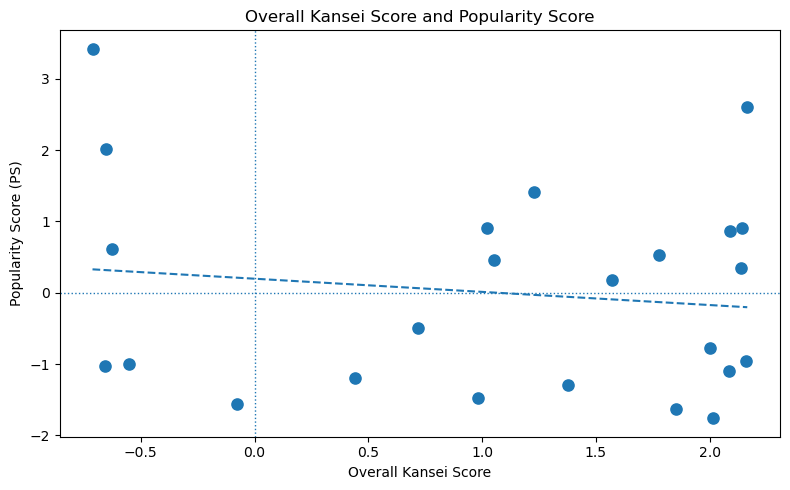

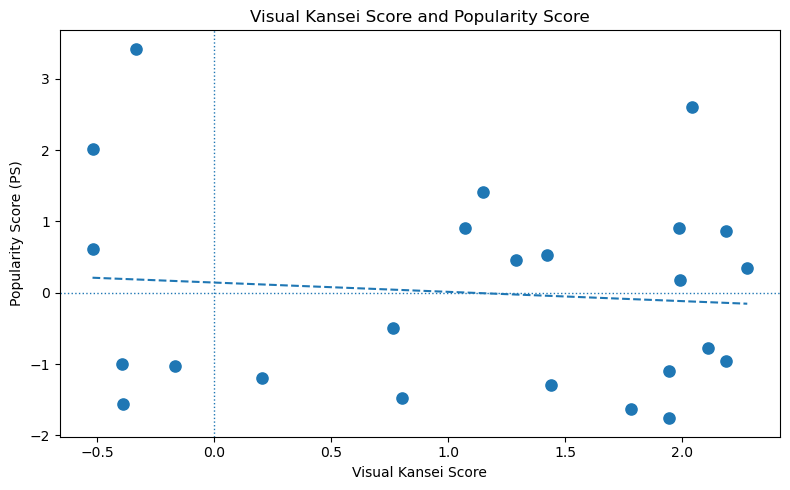

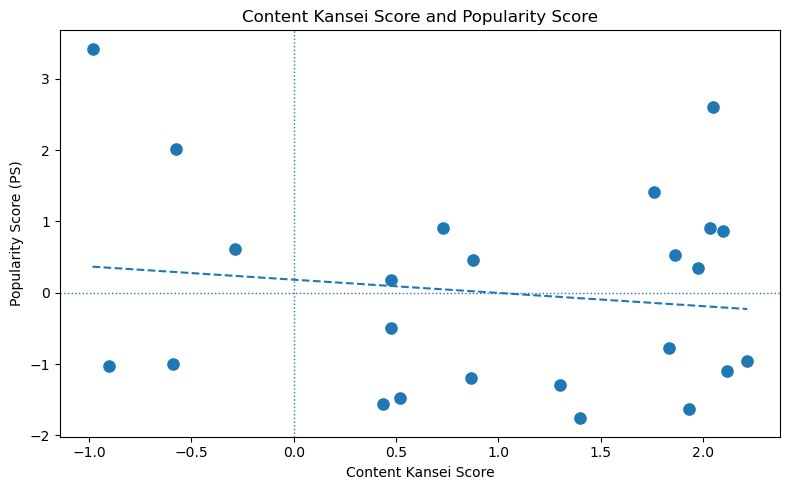

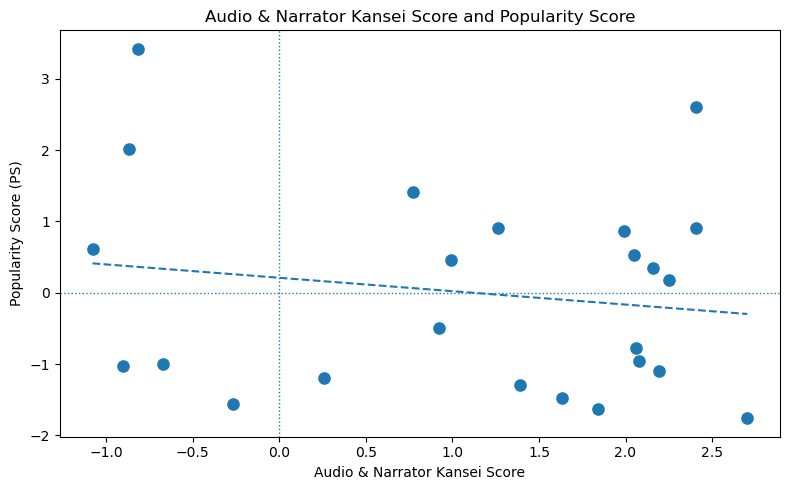

In [182]:
for kansei_column, kansei_name in (
    kansei_score_variables.items()
):

    plot_data = (
        video_analysis_complete[
            [
                kansei_column,
                "PS"
            ]
        ]
        .dropna()
    )

    if len(plot_data) < 3:
        continue

    x = plot_data[kansei_column]
    y = plot_data["PS"]

    slope, intercept, _, _, _ = (
        stats.linregress(x, y)
    )

    x_line = np.linspace(
        x.min(),
        x.max(),
        100
    )

    y_line = intercept + slope * x_line

    plt.figure(figsize=(8, 5))

    plt.scatter(
        x,
        y,
        s=65
    )

    plt.plot(
        x_line,
        y_line,
        linestyle="--"
    )

    plt.axvline(
        x=0,
        linestyle=":",
        linewidth=1
    )

    plt.axhline(
        y=0,
        linestyle=":",
        linewidth=1
    )

    plt.xlabel(kansei_name)
    plt.ylabel("Popularity Score (PS)")

    plt.title(
        f"{kansei_name} and Popularity Score"
    )

    plt.tight_layout()
    plt.show()

In [183]:
simple_regression_data = (
    video_analysis_complete[
        [
            "PS",
            "Overall_Kansei_Mean"
        ]
    ]
    .dropna()
)

simple_ps_model = smf.ols(
    formula=(
        "PS ~ Overall_Kansei_Mean"
    ),
    data=simple_regression_data
).fit()

simple_ps_model_robust = (
    simple_ps_model
    .get_robustcov_results(
        cov_type="HC3"
    )
)

print(
    simple_ps_model_robust.summary()
)

                            OLS Regression Results                            
Dep. Variable:                     PS   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                 -0.025
Method:                 Least Squares   F-statistic:                    0.2484
Date:                Thu, 16 Jul 2026   Prob (F-statistic):              0.623
Time:                        19:05:04   Log-Likelihood:                -41.731
No. Observations:                  24   AIC:                             87.46
Df Residuals:                      22   BIC:                             89.82
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.1964    

In [184]:
simple_ps_regression_result = (
    pd.DataFrame({
        "Predictor": [
            "Overall_Kansei_Mean"
        ],
        "Coefficient": [
            simple_ps_model.params[
                "Overall_Kansei_Mean"
            ]
        ],
        "Standard Error": [
            simple_ps_model.bse[
                "Overall_Kansei_Mean"
            ]
        ],
        "p-value": [
            simple_ps_model.pvalues[
                "Overall_Kansei_Mean"
            ]
        ],
        "R-squared": [
            simple_ps_model.rsquared
        ],
        "Adjusted R-squared": [
            simple_ps_model.rsquared_adj
        ]
    })
)

display(
    simple_ps_regression_result.round(4)
)

,Predictor,Coefficient,Standard Error,p-value,R-squared,Adjusted R-squared
0,Overall_Kansei_Mean,-0.1846,0.2795,0.5159,0.0194,-0.0251


In [185]:
dimension_columns = [
    "Visual_Kansei_Mean",
    "Content_Kansei_Mean",
    "Audio_Narrator_Kansei_Mean"
]

dimension_regression_data = (
    video_analysis_complete[
        ["PS"] + dimension_columns
    ]
    .dropna()
)

dimension_ps_model = smf.ols(
    formula=(
        "PS ~ "
        "Visual_Kansei_Mean + "
        "Content_Kansei_Mean + "
        "Audio_Narrator_Kansei_Mean"
    ),
    data=dimension_regression_data
).fit()

dimension_ps_model_robust = (
    dimension_ps_model
    .get_robustcov_results(
        cov_type="HC3"
    )
)

print(
    dimension_ps_model_robust.summary()
)

                            OLS Regression Results                            
Dep. Variable:                     PS   R-squared:                       0.088
Model:                            OLS   Adj. R-squared:                 -0.048
Method:                 Least Squares   F-statistic:                    0.5263
Date:                Thu, 16 Jul 2026   Prob (F-statistic):              0.669
Time:                        19:05:24   Log-Likelihood:                -40.854
No. Observations:                  24   AIC:                             89.71
Df Residuals:                      20   BIC:                             94.42
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [186]:
dimension_ps_regression_results = []

for predictor in dimension_columns:

    dimension_ps_regression_results.append({
        "Predictor": predictor,
        "Coefficient":
            dimension_ps_model.params[
                predictor
            ],
        "Standard Error":
            dimension_ps_model.bse[
                predictor
            ],
        "p-value":
            dimension_ps_model.pvalues[
                predictor
            ],
        "R-squared":
            dimension_ps_model.rsquared,
        "Adjusted R-squared":
            dimension_ps_model.rsquared_adj
    })

dimension_ps_regression_results = (
    pd.DataFrame(
        dimension_ps_regression_results
    )
)

display(
    dimension_ps_regression_results.round(4)
)

,Predictor,Coefficient,Standard Error,p-value,R-squared,Adjusted R-squared
0,Visual_Kansei_Mean,1.3143,1.1377,0.2616,0.0885,-0.0482
1,Content_Kansei_Mean,-0.2505,0.6207,0.6908,0.0885,-0.0482
2,Audio_Narrator_Kansei_Mean,-1.0251,0.8538,0.2439,0.0885,-0.0482


In [187]:
vif_data = (
    dimension_regression_data[
        dimension_columns
    ]
    .copy()
)

vif_data = sm.add_constant(
    vif_data
)

vif_results = pd.DataFrame({
    "Variable": vif_data.columns,
    "VIF": [
        variance_inflation_factor(
            vif_data.values,
            index
        )
        for index in range(
            vif_data.shape[1]
        )
    ]
})

display(vif_results.round(3))

,Variable,VIF
0,const,2.474
1,Visual_Kansei_Mean,14.539
2,Content_Kansei_Mean,4.660
3,Audio_Narrator_Kansei_Mean,12.513


### 3.3 Relationship Between Individual Kansei Words and Popularity

In [188]:
word_ps_results = []

for column in kansei_columns:

    correlation_data = (
        video_analysis_complete[
            [
                column,
                "PS"
            ]
        ]
        .dropna()
    )

    n = len(correlation_data)

    if n >= 3:

        pearson_r, pearson_p = (
            stats.pearsonr(
                correlation_data[column],
                correlation_data["PS"]
            )
        )

        spearman_rho, spearman_p = (
            stats.spearmanr(
                correlation_data[column],
                correlation_data["PS"]
            )
        )

    else:
        pearson_r = np.nan
        pearson_p = np.nan
        spearman_rho = np.nan
        spearman_p = np.nan

    word_ps_results.append({
        "Dimension":
            column_to_dimension[column],
        "Column":
            column,
        "Kansei Word":
            kansei_labels[column],
        "N Videos":
            n,
        "Pearson r":
            pearson_r,
        "Pearson p-value":
            pearson_p,
        "Spearman rho":
            spearman_rho,
        "Spearman p-value":
            spearman_p
    })

word_ps_results = pd.DataFrame(
    word_ps_results
)

In [189]:
valid_mask = (
    word_ps_results[
        "Spearman p-value"
    ].notna()
)

word_ps_results[
    "FDR Adjusted p-value"
] = np.nan

word_ps_results[
    "Significant after FDR"
] = False

if valid_mask.sum() > 0:

    reject, adjusted_p, _, _ = (
        multipletests(
            word_ps_results.loc[
                valid_mask,
                "Spearman p-value"
            ],
            alpha=0.05,
            method="fdr_bh"
        )
    )

    word_ps_results.loc[
        valid_mask,
        "FDR Adjusted p-value"
    ] = adjusted_p

    word_ps_results.loc[
        valid_mask,
        "Significant after FDR"
    ] = reject

word_ps_results = (
    word_ps_results
    .sort_values(
        "Spearman rho",
        ascending=False
    )
)

display(
    word_ps_results.round(4)
)

,Dimension,Column,Kansei Word,N Videos,Pearson r,Pearson p-value,Spearman rho,Spearman p-value,FDR Adjusted p-value,Significant after FDR
4,Visual,coherent_scattered,Coherent–Scattered,24,-0.0094,0.9654,0.0994,0.6439,0.9839,False
14,Audio_Narrator,motivating_demotivating,Motivating–Demotivating,24,-0.0193,0.9285,0.0653,0.7616,0.9839,False
9,Content,convincing_doubtful,Convincing–Doubtful,24,-0.0492,0.8194,-0.0044,0.9839,0.9839,False
3,Visual,comfortable_uncomfortable,Comfortable–Uncomfortable,24,-0.0151,0.9444,-0.0209,0.9227,0.9839,False
7,Content,interesting_boring,Interesting–Boring,24,-0.1115,0.6038,-0.0292,0.8923,0.9839,False
0,Visual,attractive_plain,Attractive–Plain,24,-0.2148,0.3134,-0.0314,0.8843,0.9839,False
8,Content,factual_misleading,Factual–Misleading,24,-0.0681,0.7518,-0.0842,0.6957,0.9839,False
5,Content,professional_amateur,Professional–Amateur,24,-0.1739,0.4164,-0.0845,0.6947,0.9839,False
2,Visual,organized_disorganized,Organized–Disorganized,24,-0.0644,0.7649,-0.0896,0.6772,0.9839,False
6,Content,understandable_confusing,Understandable–Confusing,24,-0.2225,0.2961,-0.1330,0.5357,0.9839,False


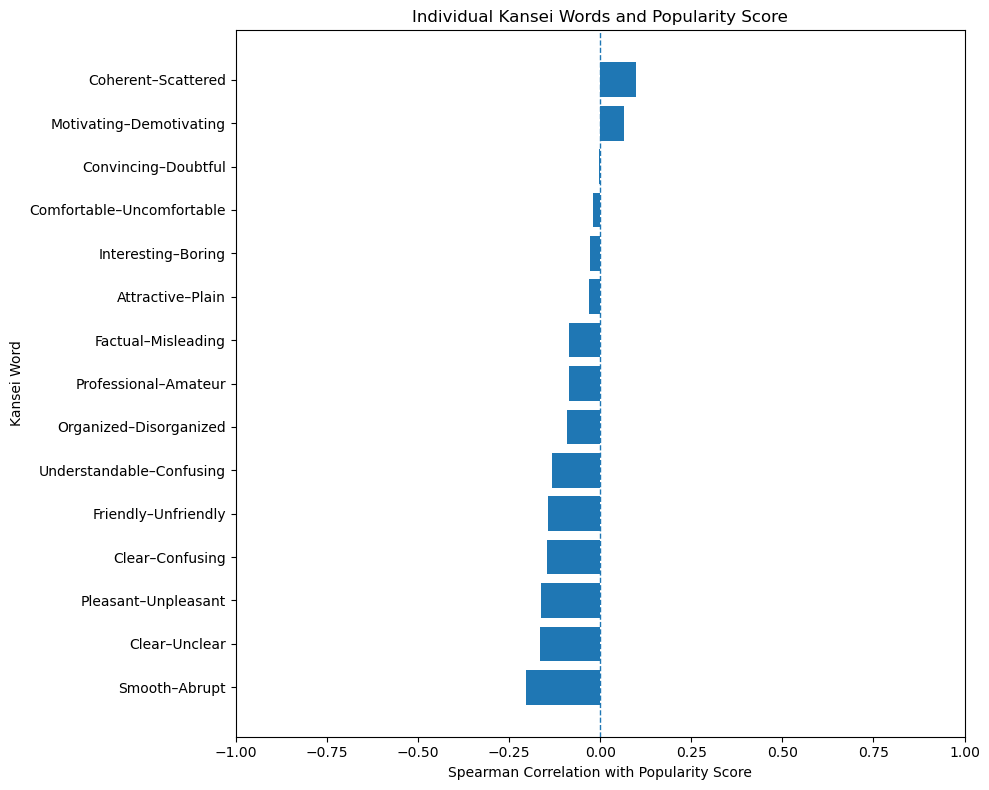

In [190]:
word_ps_plot = (
    word_ps_results
    .sort_values(
        "Spearman rho",
        ascending=True
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    word_ps_plot["Kansei Word"],
    word_ps_plot["Spearman rho"]
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Spearman Correlation with "
    "Popularity Score"
)

plt.ylabel("Kansei Word")

plt.title(
    "Individual Kansei Words and "
    "Popularity Score"
)

plt.xlim(-1, 1)

plt.tight_layout()
plt.show()

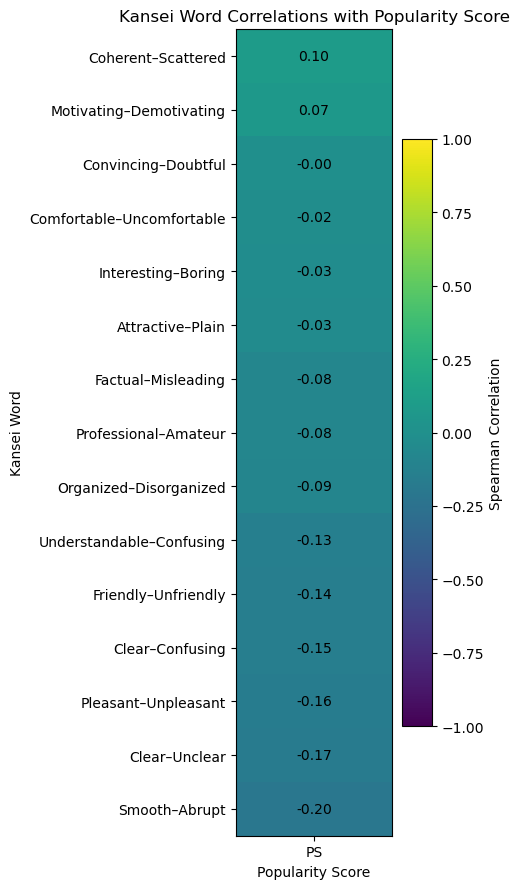

In [191]:
word_ps_heatmap = (
    word_ps_results
    .set_index("Kansei Word")[
        ["Spearman rho"]
    ]
)

plt.figure(figsize=(5, 9))

image = plt.imshow(
    word_ps_heatmap,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(
    image,
    label="Spearman Correlation"
)

plt.xticks(
    ticks=[0],
    labels=["PS"]
)

plt.yticks(
    ticks=range(
        len(word_ps_heatmap.index)
    ),
    labels=word_ps_heatmap.index
)

for row in range(
    word_ps_heatmap.shape[0]
):

    value = (
        word_ps_heatmap.iloc[
            row,
            0
        ]
    )

    plt.text(
        0,
        row,
        f"{value:.2f}",
        ha="center",
        va="center"
    )

plt.xlabel("Popularity Score")
plt.ylabel("Kansei Word")
plt.title(
    "Kansei Word Correlations "
    "with Popularity Score"
)

plt.tight_layout()
plt.show()

In [192]:
top_positive_words = (
    word_ps_results.nlargest(
        5,
        "Spearman rho"
    )
)

top_negative_words = (
    word_ps_results.nsmallest(
        5,
        "Spearman rho"
    )
)

print(
    "Strongest positive relationships:"
)

display(
    top_positive_words[
        [
            "Dimension",
            "Kansei Word",
            "Spearman rho",
            "Spearman p-value",
            "FDR Adjusted p-value"
        ]
    ].round(4)
)

print(
    "Strongest negative relationships:"
)

display(
    top_negative_words[
        [
            "Dimension",
            "Kansei Word",
            "Spearman rho",
            "Spearman p-value",
            "FDR Adjusted p-value"
        ]
    ].round(4)
)

Strongest positive relationships:


,Dimension,Kansei Word,Spearman rho,Spearman p-value,FDR Adjusted p-value
4,Visual,Coherent–Scattered,0.0994,0.6439,0.9839
14,Audio_Narrator,Motivating–Demotivating,0.0653,0.7616,0.9839
9,Content,Convincing–Doubtful,-0.0044,0.9839,0.9839
3,Visual,Comfortable–Uncomfortable,-0.0209,0.9227,0.9839
7,Content,Interesting–Boring,-0.0292,0.8923,0.9839


Strongest negative relationships:


,Dimension,Kansei Word,Spearman rho,Spearman p-value,FDR Adjusted p-value
12,Audio_Narrator,Smooth–Abrupt,-0.2040,0.3390,0.9839
11,Audio_Narrator,Clear–Unclear,-0.1657,0.4391,0.9839
10,Audio_Narrator,Pleasant–Unpleasant,-0.1616,0.4507,0.9839
1,Visual,Clear–Confusing,-0.1464,0.4948,0.9839
13,Audio_Narrator,Friendly–Unfriendly,-0.1429,0.5053,0.9839


### 3.4 Popular vs. Unpopular Video Comparison

In [193]:
ps_median = (
    video_analysis_complete[
        "PS"
    ].median()
)

video_analysis_complete[
    "Popularity_Group"
] = np.where(
    video_analysis_complete[
        "PS"
    ] >= ps_median,
    "Popular",
    "Unpopular"
)

print(
    "PS median:",
    round(ps_median, 4)
)

print(
    video_analysis_complete[
        "Popularity_Group"
    ].value_counts()
)

PS median: -0.1574
Popularity_Group
Popular      12
Unpopular    12
Name: count, dtype: int64


In [194]:
popularity_group_check_columns = [
    "group",
    "video_id",
    "video_id_count",
    "video_title",
    "Topic",
    "ER_z",
    "TP_z",
    "PS",
    "Popularity_Group"
]

popularity_group_check_columns = [
    column
    for column in popularity_group_check_columns
    if column in video_analysis_complete.columns
]

display(
    video_analysis_complete[
        popularity_group_check_columns
    ]
    .sort_values(
        "PS",
        ascending=False
    )
    .round(4)
)

,group,video_id,video_id_count,video_title,Topic,ER_z,TP_z,PS,Popularity_Group
8,A,S01,V09,Video A04,Science,-0.8960,4.3163,3.4203,Popular
20,B,S01,V21,Video B04,Science,2.8540,-0.2503,2.6036,Popular
0,A,H01,V01,Video A01,History,2.3032,-0.2893,2.0139,Popular
12,B,H01,V13,Video B01,History,0.6063,0.8043,1.4106,Popular
16,B,L01,V17,Video B09,Language,0.5951,0.3157,0.9107,Popular
5,A,L02,V06,Video A06,Language,0.0451,0.8631,0.9082,Popular
4,A,L01,V05,Video A09,Language,0.3947,0.4671,0.8618,Popular
1,A,H02,V02,Video A02,History,0.3426,0.2724,0.6150,Popular
21,B,S02,V22,Video B07,Science,0.9060,-0.3810,0.5249,Popular
13,B,H02,V14,Video B02,History,0.8152,-0.3503,0.4649,Popular


In [195]:
comparison_variables = {
    "Overall_Kansei_Mean":
        "Overall Kansei",

    "Visual_Kansei_Mean":
        "Visual",

    "Content_Kansei_Mean":
        "Content",

    "Audio_Narrator_Kansei_Mean":
        "Audio & Narrator"
}

In [196]:
popular_group_summary_rows = []

for score_column, score_name in (
    comparison_variables.items()
):

    for popularity_group in [
        "Popular",
        "Unpopular"
    ]:

        values = (
            video_analysis_complete.loc[
                video_analysis_complete[
                    "Popularity_Group"
                ] == popularity_group,
                score_column
            ]
            .dropna()
        )

        popular_group_summary_rows.append({
            "Kansei Measure":
                score_name,
            "Popularity Group":
                popularity_group,
            "Mean":
                values.mean(),
            "SD":
                values.std(ddof=1),
            "Median":
                values.median(),
            "N Videos":
                len(values)
        })

popular_group_summary = pd.DataFrame(
    popular_group_summary_rows
)

display(
    popular_group_summary.round(4)
)

,Kansei Measure,Popularity Group,Mean,SD,Median,N Videos
0,Overall Kansei,Popular,1.0992,1.1412,1.3994,12
1,Overall Kansei,Unpopular,1.0289,1.0492,1.1798,12
2,Visual,Popular,1.1695,1.0627,1.3545,12
3,Visual,Unpopular,1.0173,1.0088,1.1189,12
4,Content,Popular,1.0013,1.1310,1.3173,12
5,Content,Unpopular,0.9662,1.0225,1.0823,12
6,Audio & Narrator,Popular,1.1269,1.3475,1.6254,12
7,Audio & Narrator,Unpopular,1.1031,1.2182,1.5098,12


In [197]:
popular_unpopular_results = []

for score_column, score_name in (
    comparison_variables.items()
):

    popular_values = (
        video_analysis_complete.loc[
            video_analysis_complete[
                "Popularity_Group"
            ] == "Popular",
            score_column
        ]
        .dropna()
    )

    unpopular_values = (
        video_analysis_complete.loc[
            video_analysis_complete[
                "Popularity_Group"
            ] == "Unpopular",
            score_column
        ]
        .dropna()
    )

    if (
        len(popular_values) > 0
        and len(unpopular_values) > 0
    ):

        u_statistic, raw_p = (
            stats.mannwhitneyu(
                popular_values,
                unpopular_values,
                alternative="two-sided",
                method="auto"
            )
        )

        rank_biserial = (
            (
                2 * u_statistic
            )
            /
            (
                len(popular_values)
                * len(unpopular_values)
            )
            - 1
        )

        pooled_denominator = (
            len(popular_values)
            + len(unpopular_values)
            - 2
        )

        if pooled_denominator > 0:

            pooled_variance = (
                (
                    len(popular_values) - 1
                )
                * popular_values.var(ddof=1)
                +
                (
                    len(unpopular_values) - 1
                )
                * unpopular_values.var(ddof=1)
            ) / pooled_denominator

            pooled_sd = np.sqrt(
                pooled_variance
            )

            if pooled_sd > 0:
                cohens_d = (
                    popular_values.mean()
                    - unpopular_values.mean()
                ) / pooled_sd
            else:
                cohens_d = np.nan

        else:
            cohens_d = np.nan

    else:
        u_statistic = np.nan
        raw_p = np.nan
        rank_biserial = np.nan
        cohens_d = np.nan

    popular_unpopular_results.append({
        "Kansei Measure":
            score_name,
        "Kansei Column":
            score_column,
        "Popular N":
            len(popular_values),
        "Unpopular N":
            len(unpopular_values),
        "Popular Mean":
            popular_values.mean(),
        "Unpopular Mean":
            unpopular_values.mean(),
        "Mean Difference":
            popular_values.mean()
            - unpopular_values.mean(),
        "Mann-Whitney U":
            u_statistic,
        "Raw p-value":
            raw_p,
        "Rank-Biserial Correlation":
            rank_biserial,
        "Cohen d":
            cohens_d
    })

popular_unpopular_results = (
    pd.DataFrame(
        popular_unpopular_results
    )
)

In [198]:
valid_mask = (
    popular_unpopular_results[
        "Raw p-value"
    ].notna()
)

popular_unpopular_results[
    "Adjusted p-value"
] = np.nan

popular_unpopular_results[
    "Significant"
] = False

if valid_mask.sum() > 0:

    reject, adjusted_p, _, _ = (
        multipletests(
            popular_unpopular_results.loc[
                valid_mask,
                "Raw p-value"
            ],
            alpha=0.05,
            method="holm"
        )
    )

    popular_unpopular_results.loc[
        valid_mask,
        "Adjusted p-value"
    ] = adjusted_p

    popular_unpopular_results.loc[
        valid_mask,
        "Significant"
    ] = reject

display(
    popular_unpopular_results.round(4)
)

,Kansei Measure,Kansei Column,Popular N,Unpopular N,Popular Mean,Unpopular Mean,Mean Difference,Mann-Whitney U,Raw p-value,Rank-Biserial Correlation,Cohen d,Adjusted p-value,Significant
0,Overall Kansei,Overall_Kansei_Mean,12,12,1.0992,1.0289,0.0704,79.0,0.7075,0.0972,0.0642,1.0,False
1,Visual,Visual_Kansei_Mean,12,12,1.1695,1.0173,0.1522,80.0,0.6650,0.1111,0.1469,1.0,False
2,Content,Content_Kansei_Mean,12,12,1.0013,0.9662,0.0352,76.0,0.8399,0.0556,0.0326,1.0,False
3,Audio & Narrator,Audio_Narrator_Kansei_Mean,12,12,1.1269,1.1031,0.0238,75.0,0.8852,0.0417,0.0185,1.0,False


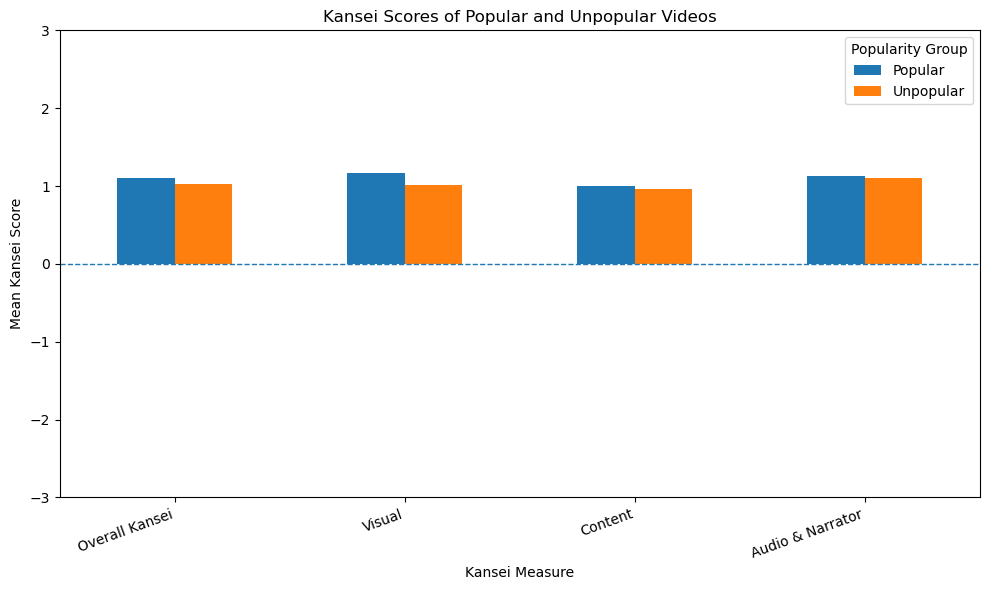

In [199]:
popular_group_plot = (
    popular_group_summary
    .pivot(
        index="Kansei Measure",
        columns="Popularity Group",
        values="Mean"
    )
    .reindex(
        [
            "Overall Kansei",
            "Visual",
            "Content",
            "Audio & Narrator"
        ]
    )
)

popular_group_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Kansei Measure")
plt.ylabel("Mean Kansei Score")

plt.title(
    "Kansei Scores of Popular and "
    "Unpopular Videos"
)

plt.ylim(-3, 3)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend(
    title="Popularity Group"
)

plt.tight_layout()
plt.show()

In [200]:
word_group_results = []

for column in kansei_columns:

    popular_values = (
        video_analysis_complete.loc[
            video_analysis_complete[
                "Popularity_Group"
            ] == "Popular",
            column
        ]
        .dropna()
    )

    unpopular_values = (
        video_analysis_complete.loc[
            video_analysis_complete[
                "Popularity_Group"
            ] == "Unpopular",
            column
        ]
        .dropna()
    )

    if (
        len(popular_values) > 0
        and len(unpopular_values) > 0
    ):

        u_statistic, raw_p = (
            stats.mannwhitneyu(
                popular_values,
                unpopular_values,
                alternative="two-sided",
                method="auto"
            )
        )

        rank_biserial = (
            (
                2 * u_statistic
            )
            /
            (
                len(popular_values)
                * len(unpopular_values)
            )
            - 1
        )

    else:
        u_statistic = np.nan
        raw_p = np.nan
        rank_biserial = np.nan

    word_group_results.append({
        "Dimension":
            column_to_dimension[column],
        "Column":
            column,
        "Kansei Word":
            kansei_labels[column],
        "Popular Mean":
            popular_values.mean(),
        "Unpopular Mean":
            unpopular_values.mean(),
        "Mean Difference":
            popular_values.mean()
            - unpopular_values.mean(),
        "Mann-Whitney U":
            u_statistic,
        "Raw p-value":
            raw_p,
        "Rank-Biserial Correlation":
            rank_biserial
    })

word_group_results = pd.DataFrame(
    word_group_results
)

In [201]:
valid_mask = (
    word_group_results[
        "Raw p-value"
    ].notna()
)

word_group_results[
    "FDR Adjusted p-value"
] = np.nan

word_group_results[
    "Significant after FDR"
] = False

if valid_mask.sum() > 0:

    reject, adjusted_p, _, _ = (
        multipletests(
            word_group_results.loc[
                valid_mask,
                "Raw p-value"
            ],
            alpha=0.05,
            method="fdr_bh"
        )
    )

    word_group_results.loc[
        valid_mask,
        "FDR Adjusted p-value"
    ] = adjusted_p

    word_group_results.loc[
        valid_mask,
        "Significant after FDR"
    ] = reject

word_group_results = (
    word_group_results
    .sort_values(
        "Mean Difference",
        ascending=False
    )
)

display(
    word_group_results.round(4)
)

,Dimension,Column,Kansei Word,Popular Mean,Unpopular Mean,Mean Difference,Mann-Whitney U,Raw p-value,Rank-Biserial Correlation,FDR Adjusted p-value,Significant after FDR
4,Visual,coherent_scattered,Coherent–Scattered,1.5083,1.1375,0.3708,87.0,0.4011,0.2083,1.0,False
3,Visual,comfortable_uncomfortable,Comfortable–Uncomfortable,1.3583,1.0250,0.3333,78.0,0.7504,0.0833,1.0,False
14,Audio_Narrator,motivating_demotivating,Motivating–Demotivating,0.7208,0.4333,0.2875,82.5,0.5629,0.1458,1.0,False
13,Audio_Narrator,friendly_unfriendly,Friendly–Unfriendly,1.5417,1.3667,0.1750,73.5,0.9536,0.0208,1.0,False
9,Content,convincing_doubtful,Convincing–Doubtful,1.1458,0.9750,0.1708,76.5,0.8169,0.0625,1.0,False
2,Visual,organized_disorganized,Organized–Disorganized,1.2667,1.1417,0.1250,74.5,0.9076,0.0347,1.0,False
7,Content,interesting_boring,Interesting–Boring,0.6958,0.5833,0.1125,79.5,0.6855,0.1042,1.0,False
1,Visual,clear_confusing,Clear–Confusing,1.3333,1.2500,0.0833,73.0,0.9769,0.0139,1.0,False
8,Content,factual_misleading,Factual–Misleading,1.2375,1.1708,0.0667,68.0,0.8393,-0.0556,1.0,False
6,Content,understandable_confusing,Understandable–Confusing,1.5083,1.4958,0.0125,71.0,0.9769,-0.0139,1.0,False


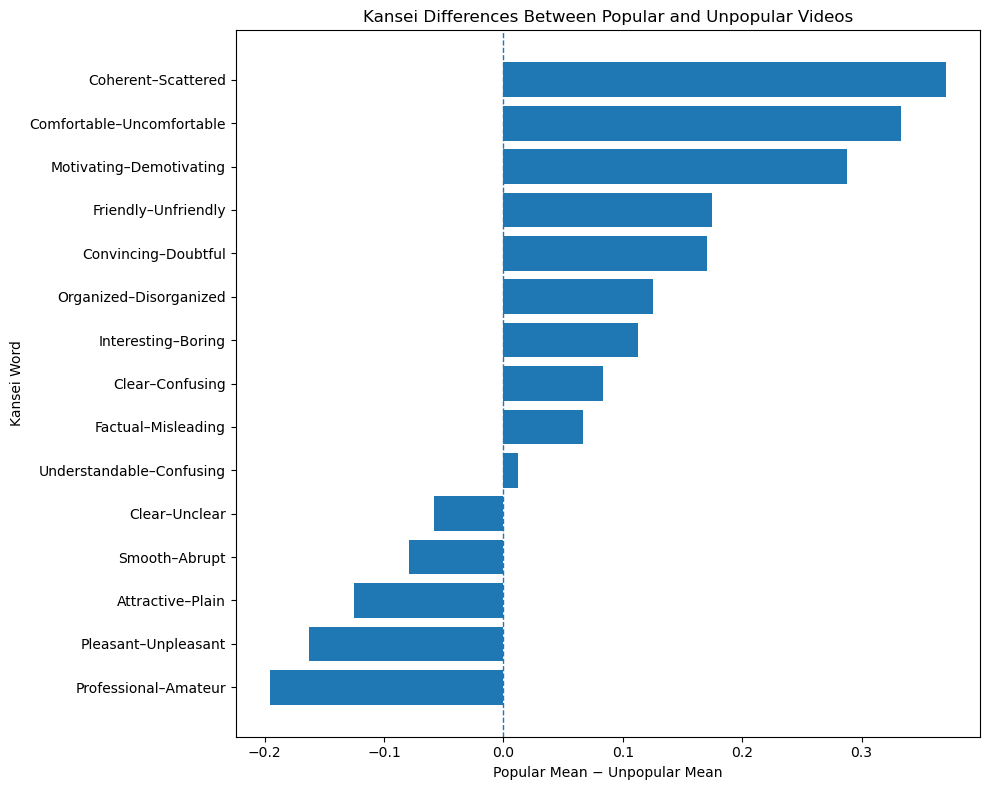

In [202]:
word_difference_plot = (
    word_group_results
    .sort_values(
        "Mean Difference",
        ascending=True
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    word_difference_plot[
        "Kansei Word"
    ],
    word_difference_plot[
        "Mean Difference"
    ]
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Popular Mean − Unpopular Mean"
)

plt.ylabel("Kansei Word")

plt.title(
    "Kansei Differences Between "
    "Popular and Unpopular Videos"
)

plt.tight_layout()
plt.show()

### 3.5 Topic × Popularity Interaction

In [203]:
topic_ps_correlations = []

for topic in topic_order:

    topic_data = (
        video_analysis_complete.loc[
            video_analysis_complete[
                "Topic"
            ] == topic,
            [
                "Overall_Kansei_Mean",
                "PS"
            ]
        ]
        .dropna()
    )

    n = len(topic_data)

    if n >= 3:

        pearson_r, pearson_p = (
            stats.pearsonr(
                topic_data[
                    "Overall_Kansei_Mean"
                ],
                topic_data["PS"]
            )
        )

        spearman_rho, spearman_p = (
            stats.spearmanr(
                topic_data[
                    "Overall_Kansei_Mean"
                ],
                topic_data["PS"]
            )
        )

    else:
        pearson_r = np.nan
        pearson_p = np.nan
        spearman_rho = np.nan
        spearman_p = np.nan

    topic_ps_correlations.append({
        "Topic": topic,
        "N Videos": n,
        "Pearson r": pearson_r,
        "Pearson p-value": pearson_p,
        "Spearman rho": spearman_rho,
        "Spearman p-value": spearman_p
    })

topic_ps_correlation_results = (
    pd.DataFrame(
        topic_ps_correlations
    )
)

display(
    topic_ps_correlation_results.round(4)
)

,Topic,N Videos,Pearson r,Pearson p-value,Spearman rho,Spearman p-value
0,Language,8,-0.1587,0.7073,-0.0952,0.8225
1,Science,8,-0.1516,0.7201,-0.0476,0.9108
2,History,8,-0.1992,0.6363,-0.3095,0.4556


In [204]:
interaction_data = (
    video_analysis_complete[
        [
            "Overall_Kansei_Mean",
            "PS",
            "Topic"
        ]
    ]
    .dropna()
    .copy()
)

interaction_data[
    "PS_Centered"
] = (
    interaction_data["PS"]
    - interaction_data["PS"].mean()
)

In [205]:
ps_interaction_model = smf.ols(
    formula=(
        "Overall_Kansei_Mean "
        "~ PS_Centered * C(Topic)"
    ),
    data=interaction_data
).fit()

ps_interaction_model_robust = (
    ps_interaction_model
    .get_robustcov_results(
        cov_type="HC3"
    )
)

print(
    ps_interaction_model_robust.summary()
)

                             OLS Regression Results                            
Dep. Variable:     Overall_Kansei_Mean   R-squared:                       0.308
Model:                             OLS   Adj. R-squared:                  0.116
Method:                  Least Squares   F-statistic:                     2.007
Date:                 Thu, 16 Jul 2026   Prob (F-statistic):              0.126
Time:                         19:08:52   Log-Likelihood:                -30.814
No. Observations:                   24   AIC:                             73.63
Df Residuals:                       18   BIC:                             80.70
Df Model:                            5                                         
Covariance Type:                   HC3                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------


In [206]:
ps_no_interaction_model = smf.ols(
    formula=(
        "Overall_Kansei_Mean "
        "~ PS_Centered + C(Topic)"
    ),
    data=interaction_data
).fit()

ps_interaction_comparison = (
    sm.stats.anova_lm(
        ps_no_interaction_model,
        ps_interaction_model
    )
)

display(
    ps_interaction_comparison.round(4)
)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,20.0,18.3293,0.0,NaN,NaN,NaN
1,18.0,18.3200,2.0,0.0093,0.0046,0.9955


In [207]:
interaction_f = (
    ps_interaction_comparison
    .iloc[-1]["F"]
)

interaction_p = (
    ps_interaction_comparison
    .iloc[-1]["Pr(>F)"]
)

interaction_result = pd.DataFrame({
    "Interaction": [
        "PS × Topic"
    ],
    "F Statistic": [
        interaction_f
    ],
    "p-value": [
        interaction_p
    ],
    "Significant": [
        interaction_p < 0.05
    ]
})

display(
    interaction_result.round(4)
)

,Interaction,F Statistic,p-value,Significant
0,PS × Topic,0.0046,0.9955,False


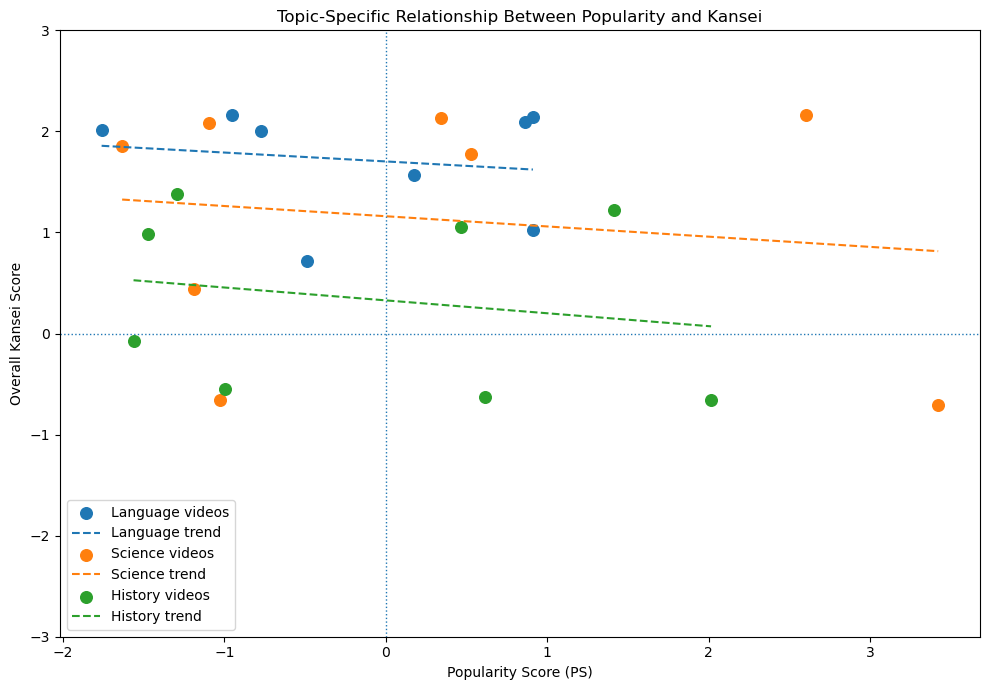

In [208]:
plt.figure(figsize=(10, 7))

for topic in topic_order:

    topic_data = (
        video_analysis_complete[
            video_analysis_complete[
                "Topic"
            ] == topic
        ]
        .dropna(
            subset=[
                "PS",
                "Overall_Kansei_Mean"
            ]
        )
    )

    if len(topic_data) < 2:
        continue

    x = topic_data["PS"]

    y = topic_data[
        "Overall_Kansei_Mean"
    ]

    slope, intercept, _, _, _ = (
        stats.linregress(x, y)
    )

    x_line = np.linspace(
        x.min(),
        x.max(),
        100
    )

    y_line = (
        intercept
        + slope * x_line
    )

    plt.scatter(
        x,
        y,
        s=70,
        label=f"{topic} videos"
    )

    plt.plot(
        x_line,
        y_line,
        linestyle="--",
        label=f"{topic} trend"
    )

plt.axhline(
    y=0,
    linestyle=":",
    linewidth=1
)

plt.axvline(
    x=0,
    linestyle=":",
    linewidth=1
)

plt.xlabel("Popularity Score (PS)")
plt.ylabel("Overall Kansei Score")

plt.title(
    "Topic-Specific Relationship Between "
    "Popularity and Kansei"
)

plt.ylim(-3, 3)

plt.legend()

plt.tight_layout()
plt.show()

In [209]:
topic_regression_results = []

for topic in topic_order:

    topic_data = (
        video_analysis_complete[
            video_analysis_complete[
                "Topic"
            ] == topic
        ]
        .dropna(
            subset=[
                "PS",
                "Overall_Kansei_Mean"
            ]
        )
    )

    if len(topic_data) < 3:
        continue

    topic_model = smf.ols(
        formula=(
            "Overall_Kansei_Mean ~ PS"
        ),
        data=topic_data
    ).fit()

    topic_regression_results.append({
        "Topic": topic,
        "N Videos": len(topic_data),
        "Intercept":
            topic_model.params[
                "Intercept"
            ],
        "PS Coefficient":
            topic_model.params["PS"],
        "PS p-value":
            topic_model.pvalues["PS"],
        "R-squared":
            topic_model.rsquared,
        "Adjusted R-squared":
            topic_model.rsquared_adj
    })

topic_regression_results = (
    pd.DataFrame(
        topic_regression_results
    )
)

display(
    topic_regression_results.round(4)
)

,Topic,N Videos,Intercept,PS Coefficient,PS p-value,R-squared,Adjusted R-squared
0,Language,8,1.7028,-0.0879,0.7073,0.0252,-0.1373
1,Science,8,1.1605,-0.1011,0.7201,0.0230,-0.1399
2,History,8,0.3280,-0.1275,0.6363,0.0397,-0.1204
